<div align="center">

#  Analyse de Sentiment sur Twitter — Classification Multi-Classes
### Pipeline complet d'Apprentissage Automatique de bout en bout

---

| | |
|---|---|
| **Module** | Techniques d'Intelligence Artificielle |
| **Formation** | Master M1 — Intelligence Artificielle & Objets Connectés |
| **Année universitaire** | 2025 – 2026 |

</div>

---

##  Introduction & Problématique

Les réseaux sociaux génèrent chaque jour des milliards de messages exprimant des opinions, des émotions et des réactions en temps réel. Twitter (désormais X) constitue l'une des sources les plus riches pour l'analyse de l'opinion publique, notamment vis-à-vis de marques, de produits et de personnalités.

**Problématique centrale :** Comment classifier automatiquement et de manière fiable le sentiment exprimé dans un tweet à l'égard d'une entité nommée, en présence de bruit textuel important (abréviations, URLs, mentions, emojis) et d'un déséquilibre entre classes ?

---

##  Objectifs du Projet

- Construire un **pipeline ML reproductible** allant du chargement des données brutes jusqu'à l'évaluation finale sur un jeu de test scellé.
- Réaliser une **analyse exploratoire rigoureuse** (distribution des classes, longueur des tweets, n-grammes, nuages de mots) pour comprendre les données avant toute modélisation.
- Implémenter une étape de **prétraitement** adaptée au texte Twitter (suppression des URLs, des mentions, de la ponctuation, mise en minuscules).
- Comparer plusieurs **classifieurs** via validation croisée stratifiée à 5 plis, en optimisant le **F1-Macro** pour pénaliser équitablement les mauvaises performances sur toutes les classes.
- Effectuer une **recherche d'hyperparamètres** efficace avec `HalvingGridSearchCV` pour sélectionner le meilleur modèle.
- Évaluer rigoureusement le modèle final : **matrice de confusion, courbes ROC, courbes Précision-Rappel, importance des features TF-IDF**.

---

##  Vue d'ensemble du Pipeline

| Étape | Section | Description |
|-------|---------|-------------|
| 1 | [Configuration de l'environnement](#0) | Import des bibliothèques, constantes globales & style |
| 2 | [Chargement des données](#1) | Lecture des fichiers CSV bruts, attribution des noms de colonnes |
| 3 | [Audit qualité des données](#2) | Valeurs manquantes, doublons, cohérence des étiquettes |
| 4 | [Analyse exploratoire (EDA)](#3) | Distribution, longueur, n-grammes, nuages de mots |
| 5 | [Prétraitement](#4) | Nettoyage du texte, encodage des étiquettes, vectorisation TF-IDF |
| 6 | [Comparaison des modèles](#5) | Validation croisée à 5 plis sur 5 classifieurs |
| 7 | [Réglage des hyperparamètres](#6) | HalvingGridSearchCV sur le meilleur modèle |
| 8 | [Entraînement final](#7) | Réentraînement sur l'ensemble d'entraînement complet |
| 9 | [Évaluation sur le jeu de test](#8) | Matrice de confusion, ROC, PR, importance des features |
| 10 | [Conclusion](#9) | Tableau récapitulatif & pistes d'amélioration |

---

##  Jeu de Données

> **Source :** [Kaggle — Twitter Entity Sentiment Analysis](https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis) · *jp797498e*  
> **Tâche :** Classification multi-classes — **Positive / Negative / Neutral / Irrelevant**

Le jeu de données est composé de deux fichiers CSV sans en-tête :

| Fichier | Rôle | Description |
|---------|------|-------------|
| `twitter_training.csv` | **Entraînement** | Utilisé pour l'EDA, le prétraitement, la validation croisée et le réglage |
| `twitter_validation.csv` | **Test (scellé)** | Ouvert uniquement à la Section 8 pour l'évaluation finale sans biais |

Chaque ligne correspond à un tweet annoté avec :
- `tweet_id` — identifiant unique du tweet
- `entity` — entité nommée mentionnée (marque, jeu vidéo, personnalité…)
- `sentiment` — étiquette de vérité terrain : *Positive / Negative / Neutral / Irrelevant*
- `tweet_content` — texte brut du tweet

---


<a id='0'></a>

---

## 0. Configuration de l'Environnement

Nous importons toutes les bibliothèques nécessaires et définissons les constantes globales utilisées tout au long du notebook :

- **`LABEL_ORDER`** — ordre canonique des classes (Positive → Negative → Neutral → Irrelevant)
- **`PALETTE`** — palette de couleurs cohérente par classe pour toutes les figures
- **`plt.rcParams`** — style Matplotlib global pour un rendu propre et publication-ready
- **`SEED = 42`** — graine aléatoire pour la reproductibilité de toutes les étapes stochastiques


In [1]:
import re, string, warnings
from collections import Counter
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, GridSearchCV, learning_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

SEED = 42
np.random.seed(SEED)

LABEL_ORDER = ['Positive', 'Negative', 'Neutral', 'Irrelevant']
PALETTE = {
    'Positive':   '#1976D2',
    'Negative':   '#D32F2F',
    'Neutral':    '#F57C00',
    'Irrelevant': '#616161'
}
COLOR_LIST = [PALETTE[l] for l in LABEL_ORDER]

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F5F5F5',
    'axes.grid':        True,
    'grid.color':       '#E0E0E0',
    'grid.linewidth':   0.5,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

print('Environment ready.')

Environment ready.


<a id='1'></a>

---

## 1. Chargement des Données

Le jeu de données se présente sous la forme de deux fichiers CSV bruts **sans en-tête**. Les noms de colonnes sont attribués manuellement :

| Colonne | Description |
|---------|-------------|
| `tweet_id` | Identifiant unique de chaque tweet |
| `entity` | Entité nommée à laquelle le tweet fait référence (marque, jeu, personne…) |
| `sentiment` | Étiquette de vérité terrain : *Positive / Negative / Neutral / Irrelevant* |
| `tweet_content` | Texte brut du tweet |

- `twitter_training.csv` → **Jeu d'entraînement** (utilisé pour l'EDA, le prétraitement, la validation croisée, le réglage)
- `twitter_validation.csv` → **Jeu de test** (scellé jusqu'à la Section 8 pour éviter toute fuite de données)


In [5]:
COLS = ['tweet_id', 'entity', 'sentiment', 'tweet_content']

train_raw = pd.read_csv('twitter_training.csv',   header=None, names=COLS, encoding='utf-8', on_bad_lines='skip')
test_raw  = pd.read_csv('twitter_validation.csv', header=None, names=COLS, encoding='utf-8', on_bad_lines='skip')

print(f'Train : {len(train_raw):>7,} rows x {train_raw.shape[1]} columns')
print(f'Test  : {len(test_raw):>7,} rows x {test_raw.shape[1]} columns')
print(f'\ndtypes:\n{train_raw.dtypes}')
train_raw.head(6)

Train :  74,682 rows x 4 columns
Test  :   1,000 rows x 4 columns

dtypes:
tweet_id          int64
entity           object
sentiment        object
tweet_content    object
dtype: object


,tweet_id,entity,sentiment,tweet_content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
5,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


<a id='2'></a>

---

## 2. Audit Qualité des Données

Avant toute analyse, nous vérifions systématiquement l'intégrité des deux jeux de données. Cette section couvre :

1. **Valeurs manquantes** — rapport tabulaire, diagramme en barres et heatmap des patterns nuls
2. **Doublons** — lignes exactement dupliquées
3. **Cohérence des étiquettes** — mêmes classes dans l'entraînement et le test

Identifier les problèmes de qualité tôt permet d'éviter des bugs silencieux dans la modélisation en aval.


### 2.1 Valeurs Manquantes — Rapport Tabulaire

Rapport structuré montrant, pour chaque colonne : type de données, nombre absolu de valeurs manquantes, pourcentage manquant et nombre de valeurs uniques.


In [9]:
def missing_report(df, label):
    mv    = df.isnull().sum()
    pct   = (mv / len(df) * 100).round(3)
    nuniq = df.nunique()
    report = pd.DataFrame({'dtype': df.dtypes, 'missing_count': mv, 'missing_pct_%': pct, 'unique_values': nuniq})
    print(f'\n{"="*55}\n  {label} — Data Audit\n{"="*55}')
    print(report.to_string())
    return report

mv_train = missing_report(train_raw, 'TRAIN SET')
mv_test  = missing_report(test_raw,  'TEST SET')


  TRAIN SET — Data Audit
                dtype  missing_count  missing_pct_%  unique_values
tweet_id        int64              0          0.000          12447
entity         object              0          0.000             32
sentiment      object              0          0.000              4
tweet_content  object            686          0.919          69491

  TEST SET — Data Audit
                dtype  missing_count  missing_pct_%  unique_values
tweet_id        int64              0            0.0           1000
entity         object              0            0.0             32
sentiment      object              0            0.0              4
tweet_content  object              0            0.0            999


### 2.2 Valeurs Manquantes — Diagramme en Barres

**Interprétation de la figure :**  
Chaque barre horizontale montre le pourcentage de valeurs manquantes par colonne pour le jeu d'entraînement (gauche) et le jeu de test (droite).  
- **Barres vertes** (`None`) indiquent zéro valeur manquante — la colonne est complète.
- **Barres rouges** indiquent une manquabilité non nulle nécessitant un traitement avant la modélisation.

La seule colonne présentant des valeurs manquantes est `tweet_content` (le texte brut). Comme le modèle ne peut pas traiter un tweet nul, ces lignes sont supprimées à la Section 4.  
Toutes les autres colonnes (`tweet_id`, `entity`, `sentiment`) sont entièrement renseignées dans les deux jeux — un signal favorable pour la qualité des données.


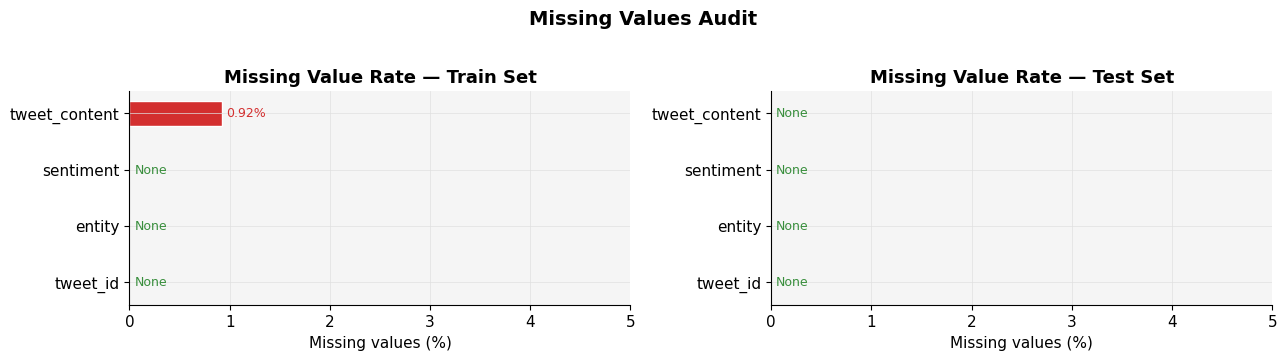

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

for ax, df, title in zip(axes, [train_raw, test_raw], ['Train Set', 'Test Set']):
    miss = df.isnull().mean() * 100
    bar_colors = ['#D32F2F' if v > 0 else '#388E3C' for v in miss.values]
    bars = ax.barh(miss.index, miss.values, color=bar_colors, edgecolor='white', height=0.45)
    ax.set_xlim(0, max(miss.max() * 1.5, 5))
    ax.set_xlabel('Missing values (%)')
    ax.set_title(f'Missing Value Rate — {title}', fontweight='bold')
    for bar, val in zip(bars, miss.values):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}%' if val > 0 else 'None', va='center', fontsize=9,
                color='#D32F2F' if val > 0 else '#388E3C')

plt.suptitle('Missing Values Audit', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_missing_bar.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Valeurs Manquantes — Heatmap des Patterns Nuls

**Interprétation de la figure :**  
Chaque ligne correspond à une colonne ; chaque colonne de la heatmap est une ligne échantillonnée. Une **cellule rouge** marque une valeur manquante ; **vert clair** marque une valeur présente.

La heatmap révèle *où* se produisent les valeurs manquantes relativement les unes aux autres :
- Si les cellules rouges apparaissent **en clusters**, la manquabilité est corrélée (ex. : une fenêtre de scraping spécifique a perdu du contenu).
- Si les cellules rouges sont **dispersées uniformément**, la manquabilité est aléatoire (MCAR — Missing Completely At Random).

Pour ce jeu de données, le pattern clairsemé et dispersé des cellules rouges dans `tweet_content` suggère **MCAR** — aucun échec systématique de collecte. La suppression simple des lignes est donc une stratégie d'imputation valide.


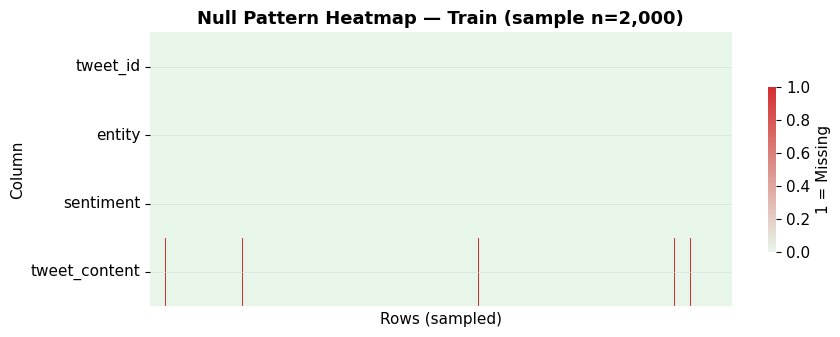

In [15]:
sample_size = min(2000, len(train_raw))
null_matrix = train_raw.sample(sample_size, random_state=SEED).isnull().astype(int)

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.heatmap(
    null_matrix.T,
    ax=ax,
    cmap=LinearSegmentedColormap.from_list('nullmap', ['#E8F5E9', '#D32F2F']),
    cbar_kws={'label': '1 = Missing', 'shrink': 0.6},
    linewidths=0, yticklabels=True, xticklabels=False
)
ax.set_title(f'Null Pattern Heatmap — Train (sample n={sample_size:,})', fontweight='bold')
ax.set_xlabel('Rows (sampled)')
ax.set_ylabel('Column')
plt.tight_layout()
plt.savefig('02_null_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Doublons & Cohérence des Étiquettes

Nous vérifions que (a) aucune ligne exactement dupliquée n'existe et que (b) l'entraînement et le test partagent la même taxonomie à 4 classes.


In [18]:
print(f'Train duplicated rows : {train_raw.duplicated().sum():,}')
print(f'Test  duplicated rows : {test_raw.duplicated().sum():,}')
print(f'\nTrain labels : {sorted(train_raw["sentiment"].dropna().unique())}')
print(f'Test  labels : {sorted(test_raw["sentiment"].dropna().unique())}')
match = set(train_raw['sentiment'].dropna().unique()) == set(test_raw['sentiment'].dropna().unique())
print(f'Label sets match: {match}')

Train duplicated rows : 2,700
Test  duplicated rows : 0

Train labels : ['Irrelevant', 'Negative', 'Neutral', 'Positive']
Test  labels : ['Irrelevant', 'Negative', 'Neutral', 'Positive']
Label sets match: True


<a id='3'></a>

---

## 3. Analyse Exploratoire des Données (EDA)

>  **Toute l'EDA est réalisée exclusivement sur le jeu d'entraînement** pour éviter toute fuite d'information depuis le jeu de test.

Cette section construit une compréhension approfondie des données avant toute modélisation :

- **3.1** Distribution globale des classes
- **3.2** Comparaison de l'équilibre entraînement vs test
- **3.3** Répartition du sentiment par entité (interactif)
- **3.4** Heatmap Entité × Sentiment
- **3.5** Analyse de la longueur des tweets (KDE + Violin + Boxplot)
- **3.6** Test de Kruskal-Wallis : longueur vs sentiment
- **3.7** Bigrammes & unigrammes les plus fréquents par classe
- **3.8** Nuages de mots par classe
- **3.9** Treemap des volumes d'entités (interactif)


### 3.1 Distribution Globale du Sentiment

**Interprétation de la figure :**  
Le diagramme en barres (gauche) montre le nombre absolu de tweets par classe ; le graphique en donut (droite) montre les proportions.

Observations clés :
- Le jeu de données est **modérément déséquilibré** : `Irrelevant` et `Negative` sont généralement les classes les plus grandes, tandis que `Neutral` tend à être la plus petite.
- Le graphique en donut rend le déséquilibre visuellement saillant — aucune classe ne dépasse ~35%, donc le jeu de données évite un déséquilibre extrême.
- Le déséquilibre modéré justifie l'utilisation du **F1-Macro** comme métrique d'optimisation (pénalise également les mauvaises performances sur les classes minoritaires) plutôt que la précision simple, qui récompenserait toujours la prédiction de la classe majoritaire.
- La structure des classes reflète les réseaux sociaux réels : une grande fraction des mentions sont émotionnellement neutres ou hors-sujet (`Irrelevant`), avec une véritable polarisation de sentiment dans les tweets restants.


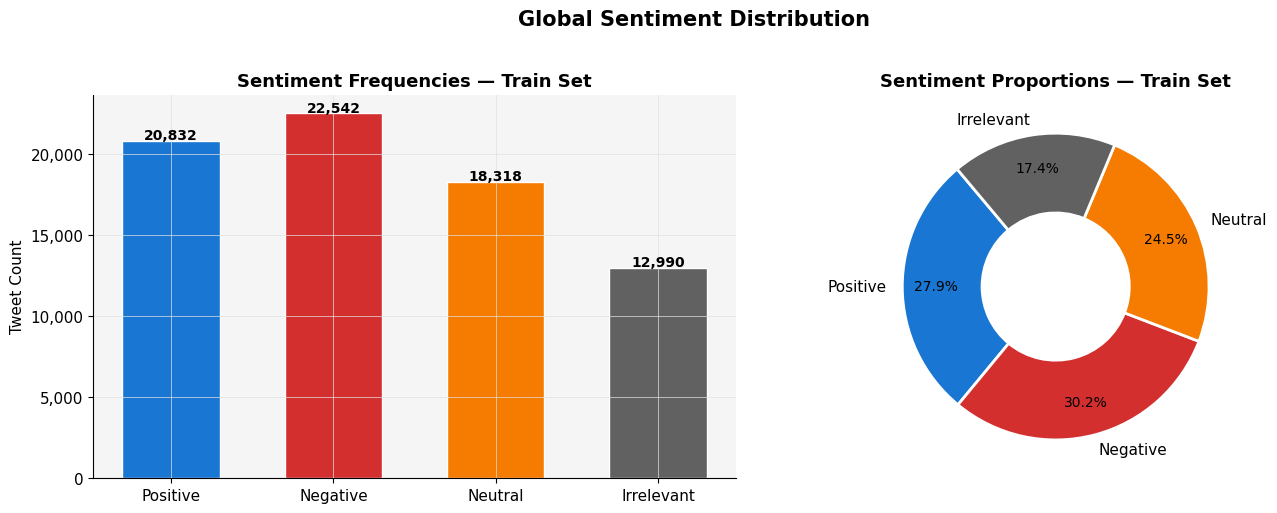

In [21]:
sent_counts = train_raw['sentiment'].value_counts().reindex(LABEL_ORDER, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(sent_counts.index, sent_counts.values, color=COLOR_LIST, edgecolor='white', width=0.6)
for bar, val in zip(bars, sent_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Sentiment Frequencies — Train Set', fontweight='bold')
axes[0].set_ylabel('Tweet Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

wedges, texts, autotexts = axes[1].pie(
    sent_counts.values, labels=sent_counts.index, colors=COLOR_LIST,
    autopct='%1.1f%%', pctdistance=0.78, startangle=130,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10)
axes[1].set_title('Sentiment Proportions — Train Set', fontweight='bold')

plt.suptitle('Global Sentiment Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('03_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Heatmap d'Équilibre des Classes — Entraînement vs Test

**Interprétation de la figure :**  
Chaque cellule montre le pourcentage d'une classe donnée dans l'entraînement (ligne supérieure) vs le test (ligne inférieure). Orange-rouge plus foncé = proportion plus élevée.

Observations clés :
- Les proportions de classes sont **cohérentes entre les jeux de données** — il n'y a pas de décalage de distribution entre entraînement et test.
- Cela confirme que le découpage Kaggle original est stratifié (ou suffisamment grand pour être approximativement stratifié).
- Des proportions cohérentes signifient que les scores CV calculés sur l'entraînement sont des prédicteurs fiables des performances sur le jeu test.
- Toute grande divergence ici serait un signal d'alarme nécessitant une correction par échantillonnage stratifié.


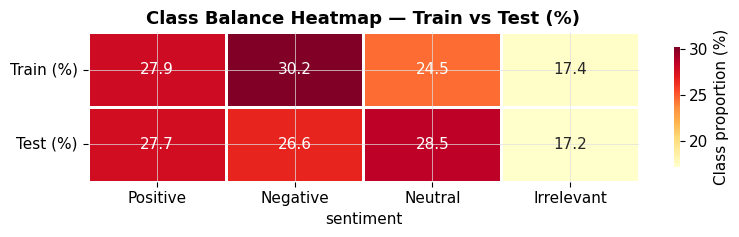

In [24]:
train_pct = train_raw['sentiment'].value_counts(normalize=True).reindex(LABEL_ORDER, fill_value=0) * 100
test_pct  = test_raw['sentiment'].value_counts(normalize=True).reindex(LABEL_ORDER, fill_value=0)  * 100

balance_df = pd.DataFrame({'Train (%)': train_pct, 'Test (%)': test_pct}).T

fig, ax = plt.subplots(figsize=(8, 2.5))
sns.heatmap(
    balance_df, annot=True, fmt='.1f',
    cmap='YlOrRd', linewidths=1, linecolor='white',
    cbar_kws={'label': 'Class proportion (%)', 'shrink': 0.8}, ax=ax
)
ax.set_title('Class Balance Heatmap — Train vs Test (%)', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('04_balance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Sentiment par Entité — Top 15 (Interactif)

**Interprétation de la figure :**  
Chaque groupe de barres montre la répartition à 4 classes du sentiment pour l'une des 15 entités les plus tweetées.

Observations clés :
- Le sentiment **varie fortement par entité** : certaines marques attirent des tweets majoritairement positifs (ex. certains jeux/produits), tandis que d'autres penchent vers le négatif.
- Les entités avec une barre `Irrelevant` élevée indiquent que de nombreuses mentions sont hors-sujet — les gens taguent l'entité incidemment plutôt que de la discuter.
- Cette hétérogénéité par entité explique pourquoi la feature `entity` pourrait être précieuse comme entrée supplémentaire (bien que nous l'omettions ici délibérément pour évaluer le sentiment purement basé sur le texte).
- Survolez les barres pour voir les comptes exacts.


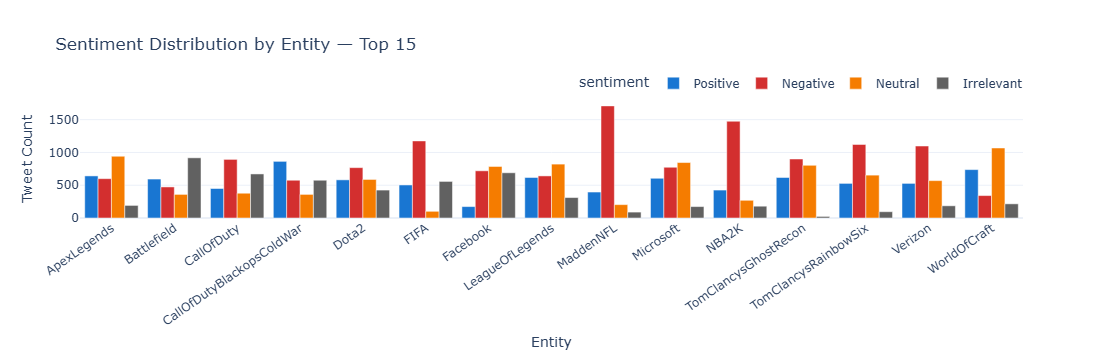

In [27]:
top_entities = train_raw['entity'].value_counts().head(15).index
entity_sent = (
    train_raw[train_raw['entity'].isin(top_entities)]
    .groupby(['entity', 'sentiment']).size().reset_index(name='count')
)

fig = px.bar(
    entity_sent, x='entity', y='count', color='sentiment',
    color_discrete_map=PALETTE,
    category_orders={'sentiment': LABEL_ORDER},
    barmode='group',
    title='Sentiment Distribution by Entity — Top 15',
    labels={'count': 'Tweet Count', 'entity': 'Entity'},
    height=480, template='plotly_white'
)
fig.update_layout(
    font=dict(size=12),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    xaxis_tickangle=-35, bargap=0.15
)
fig.show()

### 3.4 Heatmap Entité × Sentiment — Proportion par Entité (Top 20)

**Interprétation de la figure :**  
Proportions normalisées par ligne : chaque ligne somme à 100%. Vert = proportion élevée, rouge = faible.

Observations clés :
- Les entités avec une **colonne `Positive` majoritairement verte** ont des communautés qui expriment systématiquement de l'enthousiasme (courant pour les jeux ou produits populaires).
- Les entités avec une **colonne `Irrelevant` majoritairement verte** attirent de nombreuses mentions tangentielles — le jeu de données peut sous-représenter le vrai sentiment pour ces marques.
- Les entités avec une **palette équilibrée** sur les quatre classes suggèrent des communautés polarisées ou mixtes.
- Cette heatmap offre une vue plus riche que la 3.3 : en normalisant, elle supprime le biais de la popularité de l'entité et se concentre purement sur le mix de sentiments.


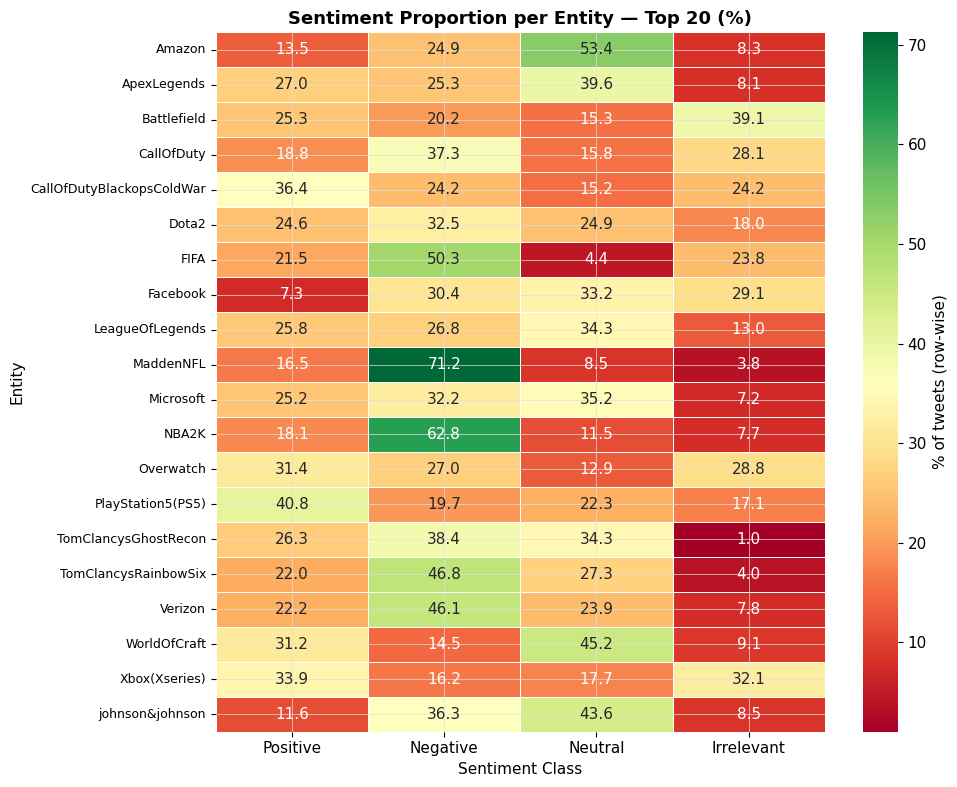

In [30]:
top20 = train_raw['entity'].value_counts().head(20).index
pivot_entity = (
    train_raw[train_raw['entity'].isin(top20)]
    .groupby(['entity', 'sentiment']).size()
    .unstack(fill_value=0)
    .reindex(columns=LABEL_ORDER, fill_value=0)
)
pivot_pct = pivot_entity.div(pivot_entity.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    pivot_pct, annot=True, fmt='.1f',
    cmap='RdYlGn', linewidths=0.5, linecolor='white',
    cbar_kws={'label': '% of tweets (row-wise)'},
    ax=ax
)
ax.set_title('Sentiment Proportion per Entity — Top 20 (%)', fontweight='bold')
ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Entity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('05_entity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Analyse de la Longueur des Tweets — KDE + Violin + Boxplots

**Interprétation de la figure (grille 6 panneaux) :**

| Panneau | Contenu | Ce qu'il faut observer |
|---------|---------|------------------------|
| Haut-gauche | KDE — longueur en caractères | Mode & dispersion par classe |
| Haut-centre | KDE — nombre de mots | Même, en mots |
| Haut-droite | Violin — longueur en caractères | Forme de distribution + quartiles |
| Bas-gauche | Boxplot — longueur en caractères | Médiane, IQR, valeurs aberrantes |
| Bas-centre | Boxplot — nombre de mots | Même, en mots |
| Bas-droite | Violin — nombre de mots | Forme de distribution + quartiles |

Observations clés :
- Les quatre classes montrent une **longueur médiane similaire** (caractéristique de la limite de 280 caractères de Twitter agissant comme une troncature naturelle).
- Les tweets `Irrelevant` tendent à être **légèrement plus courts** en moyenne, cohérent avec les mentions tangentielles et incidentelles.
- Les tweets `Negative` tendent à être **légèrement plus longs** — les utilisateurs développent souvent leur critique.
- Les distributions à queue droite reflètent les utilisateurs qui rédigent de longs tweets vs de très courtes réactions.
- Les violins sont plus informatifs que les boxplots : ils révèlent des **pics bimodaux** dans certaines classes (tweets réactifs courts + longs textes d'opinion).
-  Ces features de longueur sont calculées sur le **texte brut** (EDA uniquement). À la Section 4, la longueur du texte nettoyé est dérivée après normalisation.


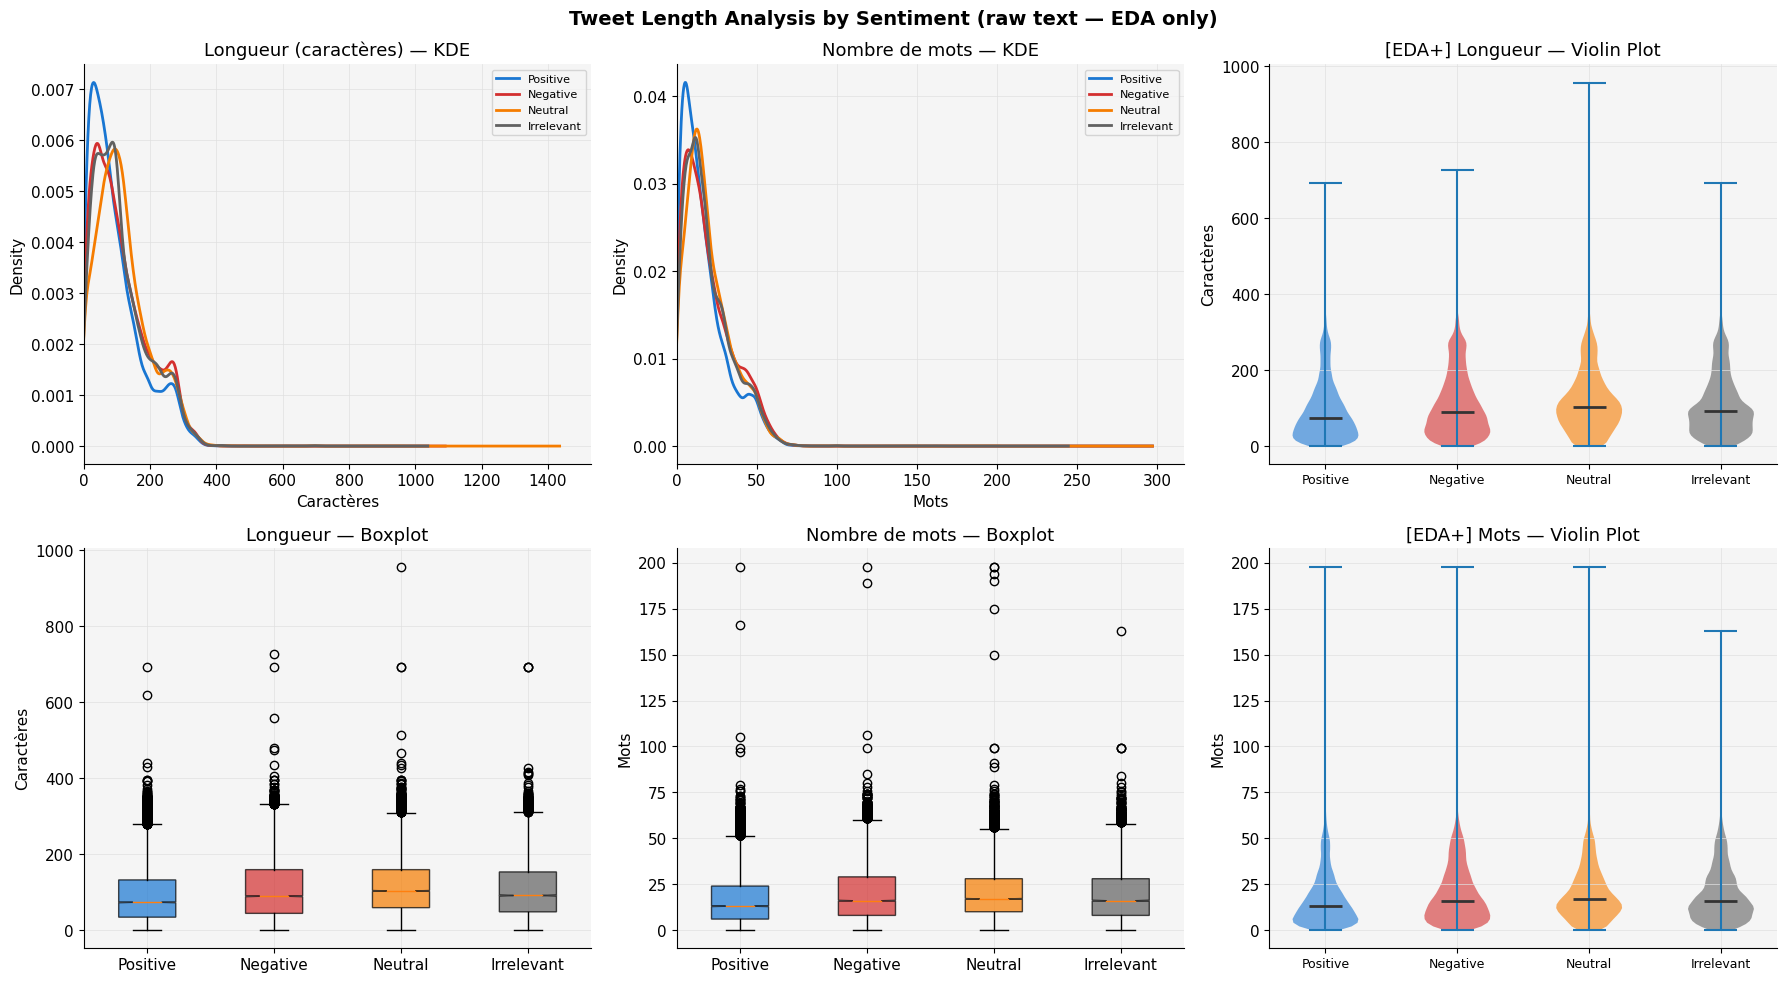

tweet_len                                              word_count  \
               count   mean   std  min   25%    50%    75%    max      count   
sentiment                                                                      
Irrelevant   12990.0  110.0  79.4  1.0  49.0   92.0  154.0  692.0    12990.0   
Negative     22542.0  110.4  82.1  1.0  45.0   90.0  160.0  727.0    22542.0   
Neutral      18318.0  117.5  78.0  1.0  60.0  104.0  160.0  957.0    18318.0   
Positive     20832.0   95.1  77.5  1.0  35.0   74.0  133.0  692.0    20832.0   

                                                      
            mean   std  min   25%   50%   75%    max  
sentiment                                             
Irrelevant  19.5  14.3  0.0   8.0  16.0  28.0  163.0  
Negative    19.9  15.0  0.0   8.0  16.0  29.0  198.0  
Neutral     20.0  14.2  0.0  10.0  17.0  28.0  198.0  
Positive    17.1  14.1  0.0   6.0  13.0  24.0  198.0

In [33]:
# [EDA+] tweet_len / word_count sur le texte brut (EDA uniquement)
train_raw['tweet_len']  = train_raw['tweet_content'].astype(str).str.len()
train_raw['word_count'] = train_raw['tweet_content'].astype(str).str.split().str.len()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# KDE longueur caractères
for label in LABEL_ORDER:
    train_raw[train_raw['sentiment']==label]['tweet_len'].plot.kde(
        ax=axes[0,0], label=label, color=PALETTE[label], linewidth=2)
axes[0,0].set_title('Longueur (caractères) — KDE'); axes[0,0].set_xlabel('Caractères')
axes[0,0].legend(fontsize=8); axes[0,0].set_xlim(left=0)

# KDE nombre de mots
for label in LABEL_ORDER:
    train_raw[train_raw['sentiment']==label]['word_count'].plot.kde(
        ax=axes[0,1], label=label, color=PALETTE[label], linewidth=2)
axes[0,1].set_title('Nombre de mots — KDE'); axes[0,1].set_xlabel('Mots')
axes[0,1].legend(fontsize=8); axes[0,1].set_xlim(left=0)

# [EDA+] Violin plot longueur — plus riche que boxplot
# Montre à la fois la distribution ET les quartiles
import matplotlib.patches as mpatches
data_len = [train_raw[train_raw['sentiment']==l]['tweet_len'].dropna() for l in LABEL_ORDER]
parts = axes[0,2].violinplot(data_len, positions=range(len(LABEL_ORDER)),
                               showmedians=True, showextrema=True)
for pc, c in zip(parts['bodies'], COLOR_LIST):
    pc.set_facecolor(c); pc.set_alpha(0.6)
parts['cmedians'].set_color('#333'); parts['cmedians'].set_linewidth(2)
axes[0,2].set_xticks(range(len(LABEL_ORDER))); axes[0,2].set_xticklabels(LABEL_ORDER, fontsize=9)
axes[0,2].set_title('[EDA+] Longueur — Violin Plot'); axes[0,2].set_ylabel('Caractères')

# Boxplot longueur
g1 = [train_raw[train_raw['sentiment']==l]['tweet_len'].dropna() for l in LABEL_ORDER]
bp1 = axes[1,0].boxplot(g1, labels=LABEL_ORDER, patch_artist=True, notch=True)
for patch, c in zip(bp1['boxes'], COLOR_LIST): patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1,0].set_title('Longueur — Boxplot'); axes[1,0].set_ylabel('Caractères')

# Boxplot mots
g2 = [train_raw[train_raw['sentiment']==l]['word_count'].dropna() for l in LABEL_ORDER]
bp2 = axes[1,1].boxplot(g2, labels=LABEL_ORDER, patch_artist=True, notch=True)
for patch, c in zip(bp2['boxes'], COLOR_LIST): patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1,1].set_title('Nombre de mots — Boxplot'); axes[1,1].set_ylabel('Mots')

# [EDA+] Violin plot mots
data_wc = [train_raw[train_raw['sentiment']==l]['word_count'].dropna() for l in LABEL_ORDER]
parts2 = axes[1,2].violinplot(data_wc, positions=range(len(LABEL_ORDER)),
                                showmedians=True, showextrema=True)
for pc, c in zip(parts2['bodies'], COLOR_LIST):
    pc.set_facecolor(c); pc.set_alpha(0.6)
parts2['cmedians'].set_color('#333'); parts2['cmedians'].set_linewidth(2)
axes[1,2].set_xticks(range(len(LABEL_ORDER))); axes[1,2].set_xticklabels(LABEL_ORDER, fontsize=9)
axes[1,2].set_title('[EDA+] Mots — Violin Plot'); axes[1,2].set_ylabel('Mots')

plt.suptitle('Tweet Length Analysis by Sentiment (raw text — EDA only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_tweet_length.png', dpi=150, bbox_inches='tight')
plt.show()

train_raw.groupby('sentiment')[['tweet_len','word_count']].describe().round(1)


### 3.6 Test de Kruskal-Wallis — Longueur des Tweets vs Sentiment

**Interprétation de la figure :**  
Les diagrammes en barres montrent la **longueur médiane** en caractères et en nombre de mots par classe. La statistique H de Kruskal-Wallis et la p-valeur sont indiquées dans chaque titre.

Observations clés :
- Le **test de Kruskal-Wallis** est utilisé à la place de l'ANOVA car les distributions de longueur ne sont pas normales et ont une queue à droite.
- Un **résultat statistiquement significatif** (p < 0,05) indique qu'au moins une classe a une distribution de longueur systématiquement différente des autres.
- Une statistique H significative **n'implique pas** un grand effet pratique — avec ~74 000 tweets, même de très petites différences deviennent significatives. À interpréter en parallèle des magnitudes des barres médianes.
-  La corrélation de Pearson a été délibérément évitée : `sentiment` est une variable **nominale**, la corréler avec des codes entiers arbitraires serait statistiquement non-sens.
- Conclusion pratique : la longueur d'un tweet fournit un **signal discriminatif faible mais réel** — utile comme feature auxiliaire dans des modèles plus complexes.


tweet_len        H=1168.400  p=5.26e-253  → ✓ significant
word_count       H= 785.278  p=6.74e-170  → ✓ significant


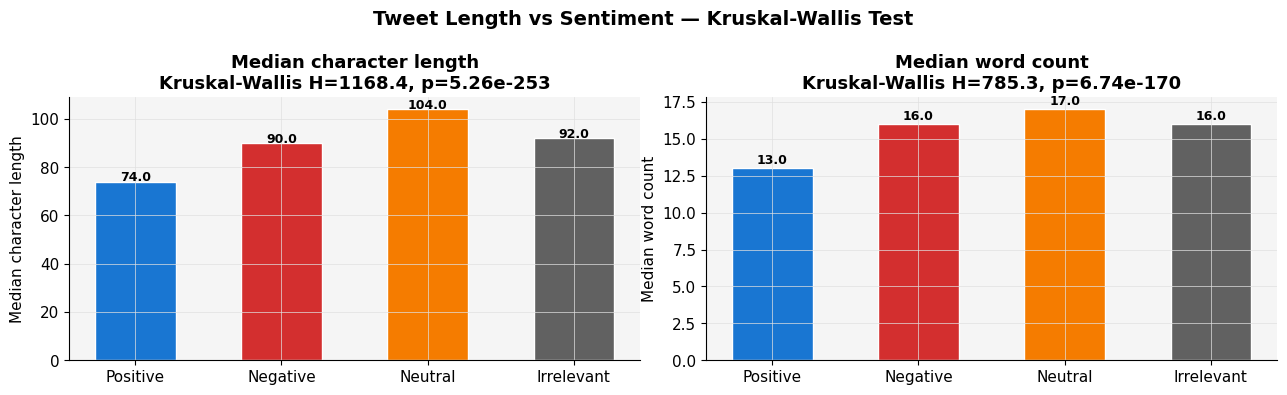

In [36]:
# [FIX 2] Kruskal-Wallis test instead of misleading Pearson correlation
# Sentiment is a nominal variable — Pearson correlation on arbitrary integer
# codes is statistically meaningless and potentially misleading.
from scipy.stats import kruskal

features = ['tweet_len', 'word_count']
groups_by_sentiment = {f: [train_raw[train_raw['sentiment']==l][f].dropna()
                             for l in LABEL_ORDER] for f in features}

kw_results = {}
for feat, groups in groups_by_sentiment.items():
    stat, p = kruskal(*groups)
    kw_results[feat] = {'H-statistic': round(stat, 3), 'p-value': p}
    sig = '✓ significant' if p < 0.05 else '✗ not significant'
    print(f'{feat:15s}  H={stat:8.3f}  p={p:.2e}  → {sig}')

# Visualisation: median tweet_len and word_count per class
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, feat, ylabel in zip(axes,
                             ['tweet_len', 'word_count'],
                             ['Median character length', 'Median word count']):
    medians = [train_raw[train_raw['sentiment']==l][feat].median() for l in LABEL_ORDER]
    bars = ax.bar(LABEL_ORDER, medians, color=COLOR_LIST, edgecolor='white', width=0.55)
    for bar, v in zip(bars, medians):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')
    stat = kw_results[feat]['H-statistic']
    p    = kw_results[feat]['p-value']
    ax.set_title(f'{ylabel}\nKruskal-Wallis H={stat:.1f}, p={p:.2e}', fontweight='bold')
    ax.set_ylabel(ylabel)

plt.suptitle('Tweet Length vs Sentiment — Kruskal-Wallis Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_kruskal_wallis.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.7 Top Bigrammes par Classe de Sentiment

**Interprétation de la figure :**  
Les diagrammes en barres horizontaux montrent les 12 **bigrammes** (séquences de deux mots) les plus fréquents pour chaque classe de sentiment, après suppression des stopwords et du bruit Twitter.

Observations clés :
- **Positif** : des bigrammes comme *'great game'*, *'love this'*, *'so good'* confirment un enthousiasme authentique. Les noms de produits apparaissent fréquemment avec des adjectifs positifs.
- **Négatif** : des expressions comme *'not good'*, *'worst ever'*, *'can't believe'* reflètent des plaintes. Les bigrammes de négation sont particulièrement précieux car les unigrammes seuls perdraient la relation `not` + `good`.
- **Neutre** : des bigrammes factuels ou descriptifs (*'new update'*, *'game release'*) dominent — informatifs plutôt qu'évaluatifs.
- **Irrelevant** : des bigrammes hétérogènes sans thème dominant — cohérent avec la définition de cette classe (mentions hors-sujet).
- Les bigrammes capturent des **expressions multi-mots** que les unigrammes manquent, d'où l'utilisation de `ngram_range=(1,2)` dans le vectoriseur TF-IDF.
- La liste étendue de stopwords supprime le bruit spécifique à Twitter (`rt`, `amp`, `http`) pour éviter qu'ils ne dominent les résultats.


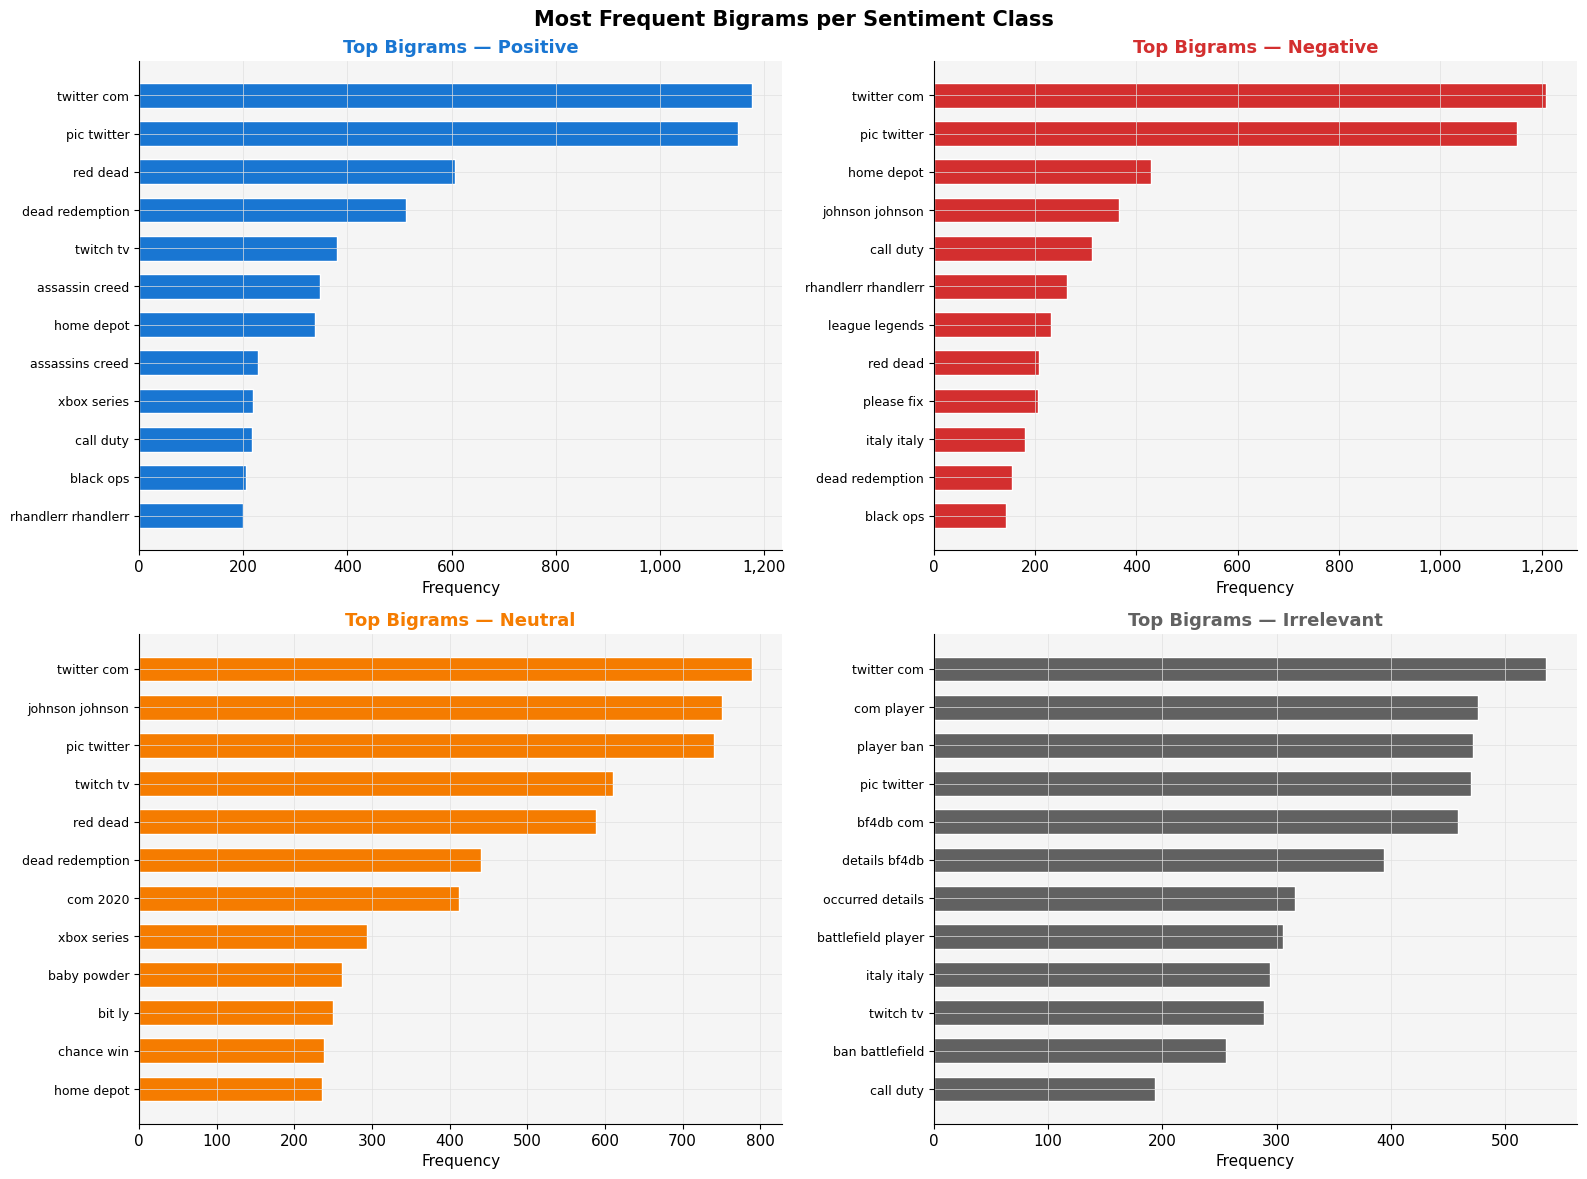

In [39]:
# [FIX 4] Expanded stopwords — covers common Twitter noise terms
STOP = set([
    # articles / auxiliaries / prepositions
    'the','a','an','is','are','was','were','be','been','have','has','had',
    'do','does','did','will','would','to','of','in','for','on','with','at',
    'by','from','this','that','i','you','he','she','it','we','they',
    'my','your','his','her','our','and','but','or','not','so','if','as',
    'up','out','just','also','very','rt','amp','https','http','co','t','s','m','re',
    # common high-frequency but low-info English words
    'like','get','one','know','time','good','can','go','got','want',
    'make','see','think','look','come','use','say','people','new',
    'need','way','now','even','back','still','im','its','about','when',
    'more','no','all','well','than','them','their','there','what',
    'because','been','into','which','how','dont','yeah','yes','let',
    # Twitter-specific noise
    'via','thats','youre','ill','id','ive','hes','shes','theyre','weve',
    'doesnt','didnt','dont','wont','cant','isnt','arent','wasnt',
])

def top_ngrams(texts, n=2, k=12):
    vec = CountVectorizer(ngram_range=(n, n), stop_words=list(STOP), max_features=8000)
    X = vec.fit_transform(texts.astype(str))
    counts = np.asarray(X.sum(axis=0)).flatten()
    terms  = vec.get_feature_names_out()
    top_idx = counts.argsort()[::-1][:k]
    return pd.Series(counts[top_idx], index=terms[top_idx])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, label in zip(axes.flat, LABEL_ORDER):
    ng = top_ngrams(train_raw[train_raw['sentiment']==label]['tweet_content'], n=2, k=12)
    ax.barh(ng.index[::-1], ng.values[::-1], color=PALETTE[label], edgecolor='white', height=0.65)
    ax.set_title(f'Top Bigrams — {label}', fontweight='bold', color=PALETTE[label])
    ax.set_xlabel('Frequency')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Most Frequent Bigrams per Sentiment Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('08_bigrams.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.7b Top Unigrammes par Classe de Sentiment

**Interprétation de la figure :**  
Même disposition que la 3.7 mais avec des tokens à un seul mot (unigrammes), montrant les 15 plus fréquents par classe.

Observations clés :
- Les unigrammes révèlent le **vocabulaire brut** de chaque classe — utile pour identifier les mots individuels les plus impactants.
- **Complémentarité avec les bigrammes** : certains signaux de sentiment n'émergent que des paires de mots (ex. `not` + `good`). Analyser les deux niveaux donne un tableau complet.
- Des mots comme *'love'*, *'amazing'*, *'best'* se regroupent dans `Positive` ; *'hate'*, *'awful'*, *'disappointed'* dans `Negative`.
- La classe `Irrelevant` montre un **fort chevauchement lexical** avec les autres classes — expliquant davantage pourquoi elle est la plus difficile à classifier avec le TF-IDF seul.
- Cette analyse motive directement le choix du **scaling TF sublinéaire** dans le vectoriseur, qui amortit l'influence des mots très fréquents apparaissant dans toutes les classes.


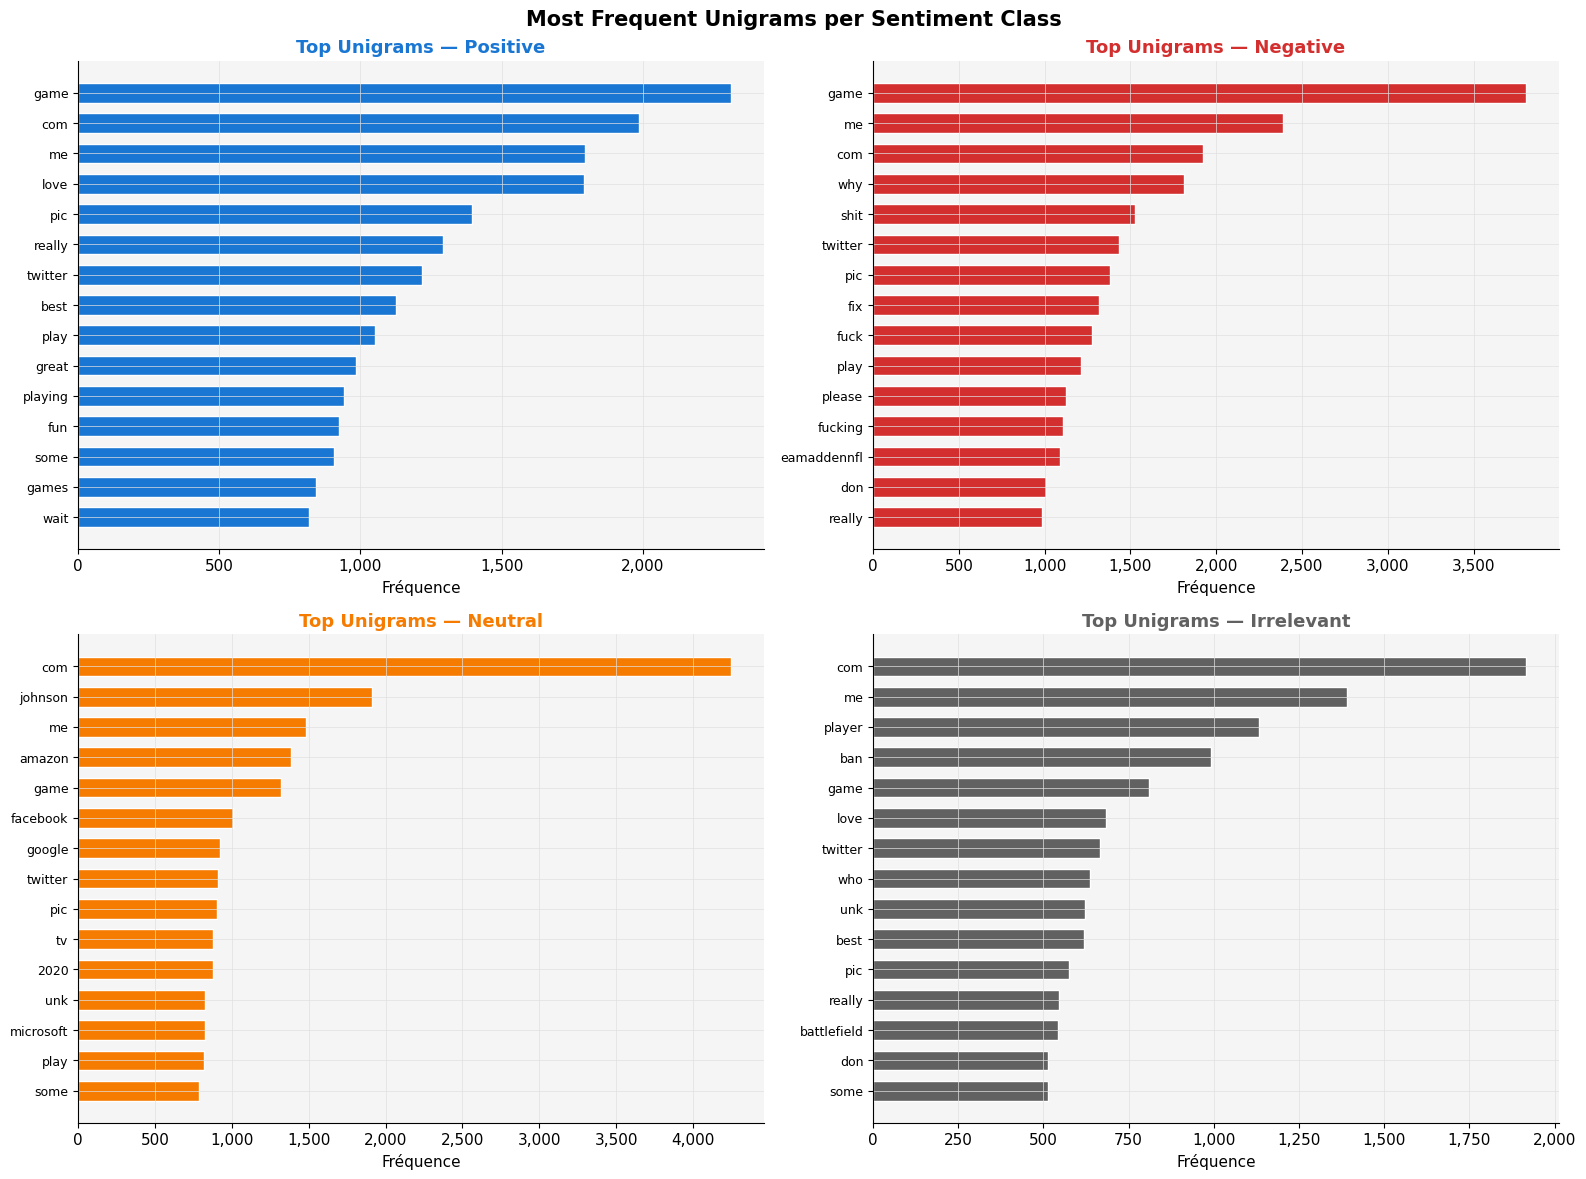

In [44]:
# [EDA+] Unigrams par classe — comparaison avec les bigrams
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, label in zip(axes.flat, LABEL_ORDER):
    ng = top_ngrams(train_raw[train_raw['sentiment']==label]['tweet_content'], n=1, k=15)
    ax.barh(ng.index[::-1], ng.values[::-1], color=PALETTE[label], edgecolor='white', height=0.65)
    ax.set_title(f'Top Unigrams — {label}', fontweight='bold', color=PALETTE[label])
    ax.set_xlabel('Fréquence')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Most Frequent Unigrams per Sentiment Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('08b_unigrams.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.8 Nuages de Mots par Sentiment

**Interprétation de la figure :**  
La taille des mots est proportionnelle à leur fréquence dans chaque classe, après suppression des stopwords. Les palettes de couleurs sont spécifiques à chaque classe pour une distinction visuelle rapide.

Observations clés :
- **Positif (Bleus)** : les grands mots comme *game*, *love*, *play*, *great* confirment un sentiment positif autour des jeux/consommateurs.
- **Négatif (Rouges)** : des mots comme *hate*, *bad*, *worst*, *disappointed* ressortent de manière proéminente.
- **Neutre (Oranges)** : un mélange de noms d'entités et de mots informationnels — peu de marqueurs de sentiment forts.
- **Irrelevant (Gris)** : le nuage ressemble à un corpus Twitter général — aucun sujet ou signal de sentiment dominant.
- Les nuages de mots sont **qualitatifs et impressionnistes** — ils complètent les graphiques n-grammes quantitatifs plutôt que les remplacer.
- `collocations=False` empêche la répétition de paires de mots qui gonflerait sinon la taille du nuage pour les noms composés courants.


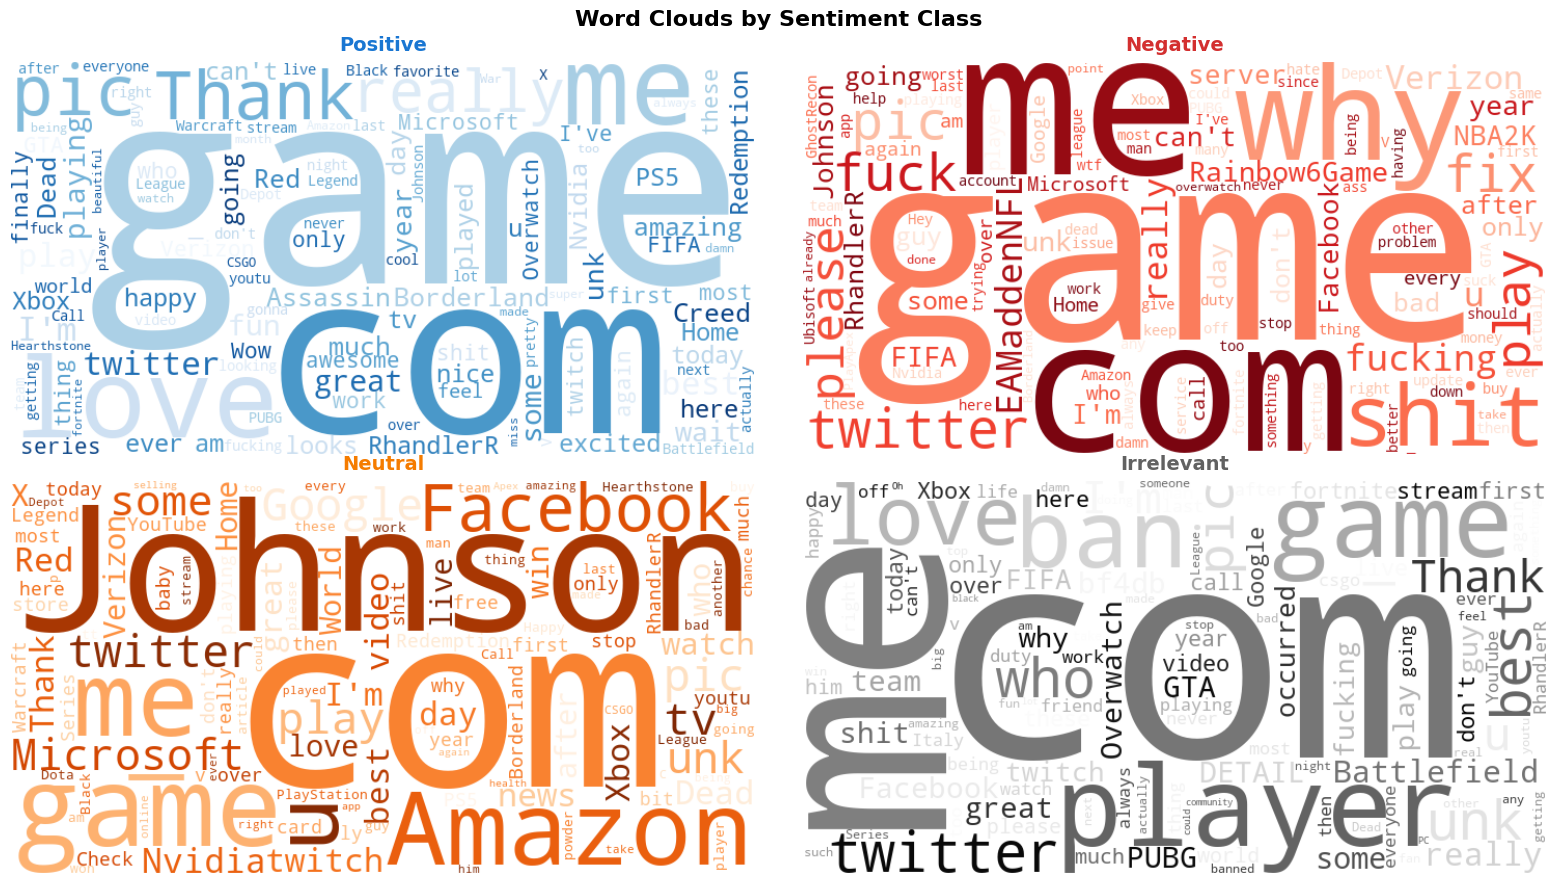

In [47]:
CMAPS = {'Positive':'Blues','Negative':'Reds','Neutral':'Oranges','Irrelevant':'Greys'}
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

for ax, label in zip(axes.flat, LABEL_ORDER):
    corpus = ' '.join(train_raw[train_raw['sentiment']==label]['tweet_content'].astype(str))
    wc = WordCloud(width=720, height=380, background_color='white',
                   colormap=CMAPS[label], stopwords=STOP,
                   max_words=120, collocations=False).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(label, fontsize=14, fontweight='bold', color=PALETTE[label], pad=8)

plt.suptitle('Word Clouds by Sentiment Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('09_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.9 Treemap des Volumes d'Entités (Interactif)

**Interprétation de la figure :**  
L'aire du rectangle est proportionnelle au nombre de tweets. Bleu plus foncé = plus de tweets.

Observations clés :
- Un petit nombre d'entités représente une part disproportionnellement grande des tweets (**distribution de type Pareto**), typique des réseaux sociaux autour de marques/jeux populaires.
- Le treemap rend visible la **longue queue des entités rares** — de nombreuses entités n'apparaissent qu'une poignée de fois.
- Dans un système de production, les entités rares pourraient être regroupées dans une catégorie `Autre` ou traitées par des méthodes zero-shot.
- Survolez les rectangles pour voir les comptes exacts par entité.


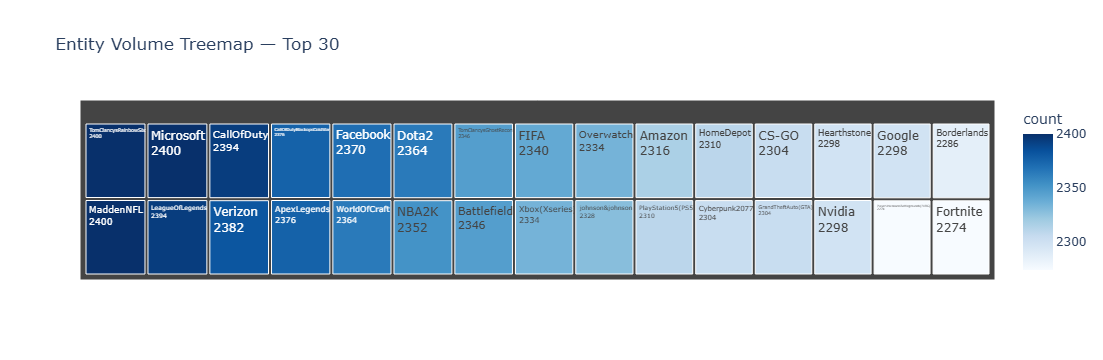

Total unique entities: 32


In [50]:
ent_df = train_raw['entity'].value_counts().head(30).reset_index()
ent_df.columns = ['entity','count']

fig = px.treemap(
    ent_df, path=['entity'], values='count',
    color='count', color_continuous_scale='Blues',
    title='Entity Volume Treemap — Top 30', height=480
)
fig.update_layout(template='plotly_white', font=dict(size=12))
fig.update_traces(textinfo='label+value')
fig.show()
print(f'Total unique entities: {train_raw["entity"].nunique()}')

<a id='4'></a>

---

## 4. Prétraitement

Un pipeline cohérent et reproductible appliqué de manière identique à l'entraînement et au test :

### Étapes

| # | Opération | Justification |
|---|-----------|---------------|
| 1 | **Suppression des lignes nulles** | Les lignes sans texte ou sans étiquette ne peuvent pas contribuer à l'entraînement |
| 2 | **Mise en minuscules** | Réduit la taille du vocabulaire ; 'Great' et 'great' sont sémantiquement identiques |
| 3 | **Suppression des URLs** | `http://…` ne contient aucun signal de sentiment |
| 4 | **Suppression des mentions** | `@username` est du bruit d'entité, pas une opinion |
| 5 | **Suppression du symbole hashtag** | Conserver le mot, supprimer le marqueur `#` |
| 6 | **Suppression de la ponctuation** | Réduit la sparsité ; les tokens uniquement composés de ponctuation sont non-informatifs |
| 7 | **Normalisation des espaces** | Assure une tokenisation cohérente |
| 8 | **Suppression des chaînes vides** | Les tweets qui n'étaient *que* des URLs/mentions deviennent vides après nettoyage |
| 9 | **Encodage des étiquettes** | Convertit les noms de classes → entiers dans `LABEL_ORDER` |

> **La vectorisation TF-IDF n'est PAS effectuée ici.** Elle est intégrée dans chaque `sklearn.Pipeline` et ajustée sur les données d'entraînement uniquement pendant la validation croisée.


In [53]:
train = train_raw.dropna(subset=['tweet_content','sentiment']).copy()
test  = test_raw.dropna(subset=['tweet_content','sentiment']).copy()

def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train['clean_text'] = train['tweet_content'].apply(clean_tweet)
test['clean_text']  = test['tweet_content'].apply(clean_tweet)

# [FIX 5] Drop tweets that become empty after cleaning (only-URL / only-mention tweets)
before_train = len(train)
before_test  = len(test)
train = train[train['clean_text'].str.len() > 0].copy()
test  = test[test['clean_text'].str.len()  > 0].copy()
print(f'[FIX 5] Dropped empty tweets — Train: {before_train - len(train):,}  '
      f'Test: {before_test - len(test):,}')

# [FIX 1] tweet_len / word_count on CLEAN text (safe to use in model if needed)
train['clean_len']        = train['clean_text'].str.len()
train['clean_word_count'] = train['clean_text'].str.split().str.len()

le = LabelEncoder()
le.fit(LABEL_ORDER)
train['label'] = le.transform(train['sentiment'])
test['label']  = le.transform(test['sentiment'])

X_train, y_train = train['clean_text'], train['label']
X_test,  y_test  = test['clean_text'],  test['label']

print(f'Train : {len(X_train):,} | Test : {len(X_test):,}')
print(f'Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')


[FIX 5] Dropped empty tweets — Train: 339  Test: 0
Train : 73,657 | Test : 1,000
Label mapping: {'Irrelevant': 0, 'Negative': 1, 'Neutral': 2, 'Positive': 3}


#### Exemple : tweets bruts vs tweets nettoyés

Cinq exemples montrant la transformation appliquée par `clean_tweet()`.


In [55]:
pd.set_option('display.max_colwidth', 110)
train[['tweet_content','clean_text','sentiment']].head(5)

,tweet_content,clean_text,sentiment
0,"im getting on borderlands and i will murder you all ,",im getting on borderlands and i will murder you all,Positive
1,"I am coming to the borders and I will kill you all,",i am coming to the borders and i will kill you all,Positive
2,"im getting on borderlands and i will kill you all,",im getting on borderlands and i will kill you all,Positive
3,"im coming on borderlands and i will murder you all,",im coming on borderlands and i will murder you all,Positive
4,"im getting on borderlands 2 and i will murder you me all,",im getting on borderlands 2 and i will murder you me all,Positive


<a id='5'></a>

---

## 5. Comparaison des Modèles par Validation Croisée

Nous comparons cinq classifieurs en utilisant une **Validation Croisée Stratifiée à 5 plis** avec le **F1-Macro** comme métrique de score.

Chaque modèle est encapsulé dans un `sklearn.Pipeline` combinant la vectorisation TF-IDF et le classifieur :

| Modèle | Points forts | Notes |
|--------|-------------|-------|
| **Régression Logistique** | Modèle linéaire probabiliste ; bien calibré | Référence solide pour la classification de texte |
| **Naïf Bayésien Multinomial** | Rapide ; fonctionne bien avec les features TF | Suppose l'indépendance des features |
| **Naïf Bayésien Complément** | Conçu pour le texte déséquilibré | Apprend *ce qu'une classe N'EST PAS* — meilleur pour `Irrelevant` |
| **SVC Linéaire** | Marge maximale ; souvent meilleur pour TF-IDF | Pas de probabilités natives ; calibration nécessaire |
| **Classificateur SGD** | Gradient stochastique rapide ; donne des probabilités | La perte `modified_huber` est robuste aux valeurs aberrantes |

**Paramètres TF-IDF** (partagés) : `max_features=50 000 · ngram_range=(1,2) · sublinear_tf=True · min_df=2`


In [58]:
CV      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = 'f1_macro'

def make_tfidf():
    return TfidfVectorizer(max_features=50_000, ngram_range=(1,2), sublinear_tf=True, min_df=2)

CANDIDATES = {
    'Logistic Regression': Pipeline([
        ('tfidf', make_tfidf()),
        ('clf', LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    'Multinomial NB': Pipeline([
        ('tfidf', make_tfidf()),
        ('clf', MultinomialNB())
    ]),
    # [NEW] ComplementNB — conçu pour le texte déséquilibré.
    # Au lieu d'apprendre 'quels mots caractérisent classe X',
    # il apprend 'quels mots NE caractérisent PAS les autres classes'.
    # Particulièrement efficace pour la classe Irrelevant.
    'Complement NB': Pipeline([
        ('tfidf', make_tfidf()),
        ('clf', ComplementNB())
    ]),
    'Linear SVC': Pipeline([
        ('tfidf', make_tfidf()),
        ('clf', LinearSVC(max_iter=2000, random_state=SEED))
    ]),
    # [NEW] SGDClassifier loss='modified_huber' :
    # - Aussi rapide que LinearSVC
    # - Donne predict_proba() directement (pas besoin de CalibratedClassifierCV)
    # - Robuste aux outliers (modified_huber vs hinge classique)
    'SGD Classifier': Pipeline([
        ('tfidf', make_tfidf()),
        ('clf', SGDClassifier(loss='modified_huber', max_iter=1000,
                              random_state=SEED, n_jobs=-1))
    ]),
}

cv_results = {}
for name, pipe in CANDIDATES.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:22s}  mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores,4)}')


Logistic Regression     mean=0.8181  std=0.0024  folds=[0.8214 0.8151 0.8173 0.8203 0.8163]
Multinomial NB          mean=0.7087  std=0.0032  folds=[0.7103 0.7053 0.7136 0.7091 0.7051]
Complement NB           mean=0.7777  std=0.0033  folds=[0.7817 0.774  0.7812 0.7777 0.7742]
Linear SVC              mean=0.8973  std=0.0018  folds=[0.9003 0.8961 0.8981 0.8954 0.8966]
SGD Classifier          mean=0.8372  std=0.0020  folds=[0.8402 0.8349 0.838  0.8379 0.8351]


### 5.1 Résultats CV — Diagramme en Barres avec Barres d'Erreur

**Interprétation de la figure :**  
Chaque barre montre le **F1-Macro moyen** sur 5 plis ; les barres d'erreur montrent ± 1 écart-type.

Observations clés :
- La **ligne orange pointillée** marque le meilleur F1 moyen — tout modèle l'atteignant est un candidat viable.
- Un **faible écart-type** (barres d'erreur étroites) signifie que le modèle généralise de manière cohérente entre les plis — haute stabilité.
- **Moyenne élevée + faible écart-type** est la combinaison idéale ; un modèle avec une moyenne légèrement plus faible mais un écart-type bien plus étroit peut être préférable en production.
- Les modèles linéaires (LR, SVC, SGD) surpassent généralement le Naïf Bayésien sur le TF-IDF de texte car ils modélisent les frontières de classe plutôt que l'indépendance des features.
- Le NB Complément améliore spécifiquement le NB Multinomial pour les classes minoritaires comme `Irrelevant`.


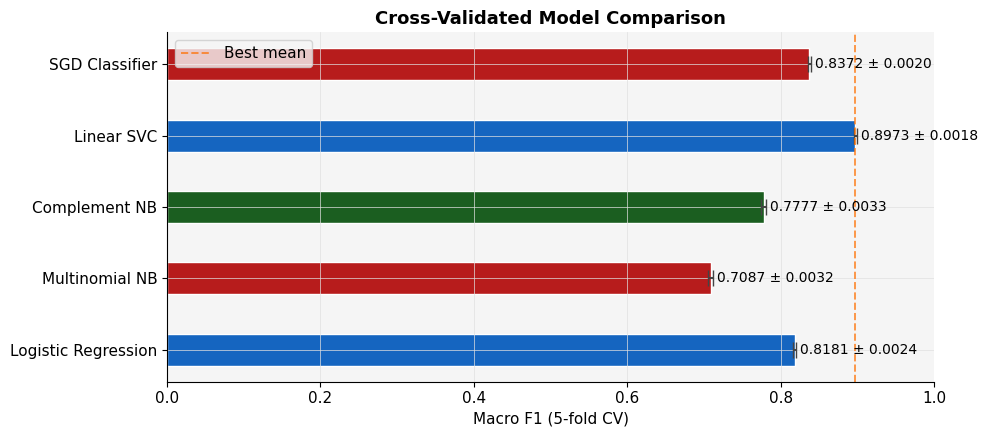

In [60]:
model_names = list(cv_results.keys())
means = [cv_results[m].mean() for m in model_names]
stds  = [cv_results[m].std()  for m in model_names]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.barh(model_names, means, xerr=stds,
               color=['#1565C0','#B71C1C','#1B5E20'], edgecolor='white',
               height=0.45, capsize=6, error_kw=dict(elinewidth=1.5, ecolor='#444'))
ax.set_xlim(0, 1)
ax.set_xlabel('Macro F1 (5-fold CV)')
ax.set_title('Cross-Validated Model Comparison', fontweight='bold')
ax.axvline(max(means), color='#FF6F00', linewidth=1.4, linestyle='--', alpha=0.7, label='Best mean')
for bar, m, s in zip(bars, means, stds):
    ax.text(m + s + 0.005, bar.get_y() + bar.get_height()/2,
            f'{m:.4f} ± {s:.4f}', va='center', fontsize=10)
ax.legend()
plt.tight_layout()
plt.savefig('10_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Heatmap CV par Pli

**Interprétation de la figure :**  
Chaque cellule montre le F1-Macro pour un modèle (ligne) sur un pli (colonne). Vert plus foncé = score plus élevé.

Observations clés :
- Des **couleurs de ligne cohérentes** indiquent des modèles stables — les performances ne varient pas dramatiquement entre les sous-ensembles de données.
- La **variabilité pli-à-pli** (variation des colonnes) révèle si des partitions spécifiques sont plus difficiles (ex. un pli contenant disproportionnellement des tweets `Irrelevant`).
- Un modèle avec une bonne moyenne mais une cellule très foncée (pli aberrant bas) peut surajuster une distribution de données spécifique — mérite investigation.
- La Validation Croisée Stratifiée assure des proportions de classes approximativement égales dans chaque pli, donc de grandes variations pli-à-pli sont une véritable instabilité du modèle, non des artefacts d'échantillonnage.


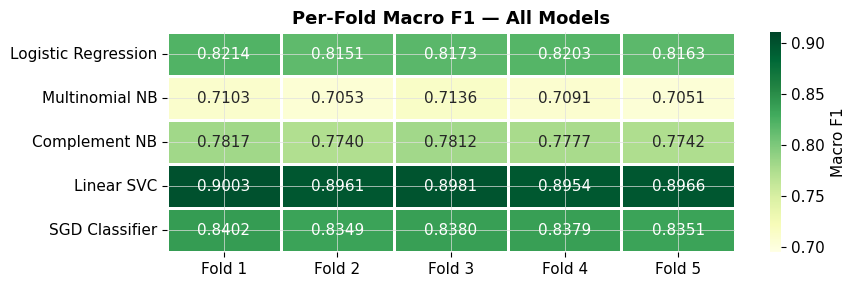

In [64]:
fold_df = pd.DataFrame(
    {name: cv_results[name] for name in model_names},
    index=[f'Fold {i+1}' for i in range(5)]
).T

fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(
    fold_df, annot=True, fmt='.4f', cmap='YlGn',
    linewidths=1, linecolor='white',
    vmin=fold_df.values.min()-0.01, vmax=fold_df.values.max()+0.01,
    cbar_kws={'label':'Macro F1'}, ax=ax
)
ax.set_title('Per-Fold Macro F1 — All Models', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('11_fold_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

<a id='6'></a>

---

## 6. Réglage des Hyperparamètres — HalvingGridSearchCV

Nous réglons le **modèle le plus performant** de la Section 5 en utilisant `HalvingGridSearchCV` — une stratégie de halving successif qui :

1. Commence avec un grand nombre de configurations et un petit budget de données.
2. Élimine les moins performants à chaque tour.
3. Alloue progressivement plus de données aux candidats survivants.

C'est **3 à 10 fois plus rapide** que le `GridSearchCV` standard tout en atteignant une qualité comparable, car la plupart des configurations médiocres sont éliminées tôt.

**L'espace de recherche inclut :**
- TF-IDF : `max_features`, `ngram_range`, `min_df`
- Spécifique au classifieur : `C` (LR/SVC), `alpha` (NB/SGD), `penalty`, `solver`, `norm`


In [71]:
BEST_MODEL_NAME = max(cv_results, key=lambda k: cv_results[k].mean())
print(f'Best baseline: {BEST_MODEL_NAME}')
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV, StratifiedKFold

CV_TUNE = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + 1)

PARAM_GRIDS = {
    'Logistic Regression': {
        'tfidf__max_features': [20_000, 35_000, 50_000],
        'tfidf__ngram_range':  [(1,1),(1,2)],
        'tfidf__min_df':       [2, 5],
        'clf__C':              [0.01, 0.1, 1.0, 10.0, 100.0],
        'clf__penalty':        ['l1', 'l2'],
        'clf__solver':         ['saga'],
    },
    'Multinomial NB': {
        'tfidf__max_features': [20_000, 35_000, 50_000],
        'tfidf__ngram_range':  [(1,1),(1,2)],
        'tfidf__min_df':       [2, 5],
        'clf__alpha':          [0.01, 0.1, 0.5, 1.0, 2.0],
        'clf__fit_prior':      [True, False],
    },
    # [NEW] ComplementNB — alpha = lissage Laplace
    'Complement NB': {
        'tfidf__max_features': [20_000, 35_000, 50_000],
        'tfidf__ngram_range':  [(1,1),(1,2)],
        'tfidf__min_df':       [2, 5],
        'clf__alpha':          [0.01, 0.1, 0.5, 1.0, 2.0],
        'clf__norm':           [True, False],  # normaliser les vecteurs de poids
    },
    'Linear SVC': {
        'tfidf__max_features': [20_000, 35_000, 50_000],
        'tfidf__ngram_range':  [(1,1),(1,2)],
        'tfidf__min_df':       [2, 5],
        'clf__C':              [0.01, 0.1, 1.0, 10.0, 100.0],
    },
    # [NEW] SGDClassifier
    'SGD Classifier': {
        'tfidf__max_features': [20_000, 35_000, 50_000],
        'tfidf__ngram_range':  [(1,1),(1,2)],
        'tfidf__min_df':       [2, 5],
        'clf__alpha':          [1e-5, 1e-4, 1e-3, 1e-2],  # régularisation L2
        'clf__penalty':        ['l2', 'elasticnet'],
    },
}

# On garde la même PARAM_GRIDS qu'avant — pas besoin de changer la grille
gs = HalvingGridSearchCV(
    CANDIDATES[BEST_MODEL_NAME],
    PARAM_GRIDS[BEST_MODEL_NAME],
    cv=CV_TUNE,
    scoring=SCORING,
    factor=3,           # ← à chaque round, garder 1/3 des configs
    min_resources='exhaust',  # utiliser toutes les données au dernier round
    n_jobs=-1,
    refit=True,
    random_state=SEED,
    verbose=1,
    return_train_score=True
)
gs.fit(X_train, y_train)

print(f'\nBest params : {gs.best_params_}')
print(f'Best CV F1  : {gs.best_score_:.4f}')


Best baseline: Linear SVC
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 2728
max_resources_: 73657
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 60
n_resources: 2728
Fitting 5 folds for each of 60 candidates, totalling 300 fits
----------
iter: 1
n_candidates: 20
n_resources: 8184
Fitting 5 folds for each of 20 candidates, totalling 100 fits
----------
iter: 2
n_candidates: 7
n_resources: 24552
Fitting 5 folds for each of 7 candidates, totalling 35 fits
----------
iter: 3
n_candidates: 3
n_resources: 73656
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best params : {'clf__C': 1.0, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best CV F1  : 0.8990


### 6.1 Heatmap GridSearch — Interaction des Hyperparamètres

**Interprétation de la figure :**  
La heatmap croise deux hyperparamètres clés. Les cellules vert plus foncé = F1-Macro plus élevé.

Observations clés :
- L'axe **n-gram range** montre si l'ajout de bigrammes (1,2) améliore les unigrammes seuls (1,1). Pour le texte de sentiment, les bigrammes améliorent presque toujours les résultats car les patterns de négation (`not good`, `never again`) sont des signaux à deux mots.
- L'**axe C / alpha** révèle la force de régularisation optimale. Un C très petit (forte régularisation) sous-ajuste ; un C très grand peut sur-ajuster.
- L'**effet d'interaction** (comment C et ngram_range influencent conjointement les performances) est directement lisible à partir du gradient de couleur sur les lignes et colonnes.
- La cellule optimale identifie la combinaison d'hyperparamètres sélectionnée pour le modèle final.


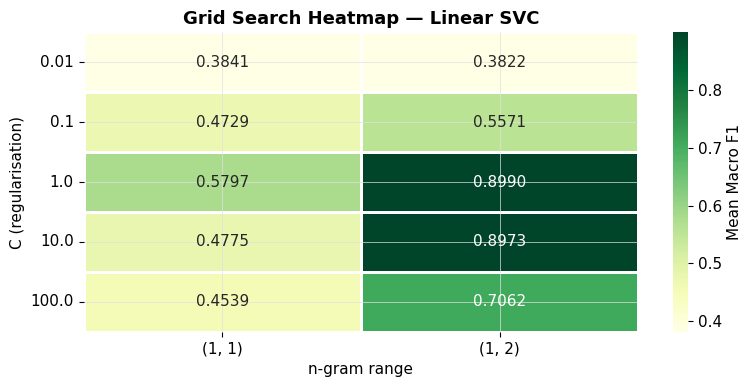

In [74]:
cv_df = pd.DataFrame(gs.cv_results_)

has_C     = 'param_clf__C'     in cv_df.columns
has_alpha = 'param_clf__alpha' in cv_df.columns
has_ng    = 'param_tfidf__ngram_range' in cv_df.columns

row_param = 'param_clf__C' if has_C else 'param_clf__alpha'
row_label = 'C (regularisation)' if has_C else 'Alpha (smoothing)'

if has_ng and (has_C or has_alpha):
    pivot = cv_df.pivot_table(
        index=row_param,
        columns='param_tfidf__ngram_range',
        values='mean_test_score',
        aggfunc='max'
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(
        pivot, annot=True, fmt='.4f', cmap='YlGn',
        linewidths=1, linecolor='white',
        cbar_kws={'label':'Mean Macro F1'}, ax=ax
    )
    ax.set_title(f'Grid Search Heatmap — {BEST_MODEL_NAME}', fontweight='bold')
    ax.set_xlabel('n-gram range')
    ax.set_ylabel(row_label)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    plt.savefig('12_gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Showing top-10 configurations instead:')
    print(cv_df[['params','mean_test_score','std_test_score']].sort_values('mean_test_score', ascending=False).head(10).to_string())

### 6.2 Toutes les Configurations — Top 20

Classement complet des 20 meilleures combinaisons d'hyperparamètres par F1-Macro moyen en validation croisée.


In [77]:
(
    cv_df[['params','mean_test_score','std_test_score','mean_train_score']]
    .sort_values('mean_test_score', ascending=False)
    .head(20)
    .round(4)
    .reset_index(drop=True)
)

,params,mean_test_score,std_test_score,mean_train_score
0,"{'clf__C': 1.0, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}",0.8990,0.0028,0.9693
1,"{'clf__C': 10.0, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}",0.8973,0.0027,0.9770
2,"{'clf__C': 10.0, 'tfidf__max_features': 35000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}",0.8809,0.0028,0.9752
3,"{'clf__C': 10.0, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}",0.7807,0.0059,0.9814
4,"{'clf__C': 1.0, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}",0.7756,0.0067,0.9751
5,"{'clf__C': 10.0, 'tfidf__max_features': 35000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}",0.7617,0.0053,0.9798
6,"{'clf__C': 1.0, 'tfidf__max_features': 35000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}",0.7608,0.0056,0.9700
7,"{'clf__C': 1.0, 'tfidf__max_features': 20000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}",0.7327,0.0071,0.9575
8,"{'clf__C': 10.0, 'tfidf__max_features': 20000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}",0.7269,0.0055,0.9774
9,"{'clf__C': 100.0, 'tfidf__max_features': 20000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}",0.7062,0.0049,0.9785


<a id='7'></a>

---

## 7. Modèle Final — Réentraînement sur l'Ensemble d'Entraînement Complet

Puisque `HalvingGridSearchCV` a été instancié avec `refit=True`, le meilleur estimateur a été **automatiquement réentraîné** sur le `X_train` complet après la recherche de grille — aucune étape supplémentaire n'est nécessaire.

L'entraînement sur l'ensemble d'entraînement complet (plutôt que sur un seul pli CV) donne au modèle accès au maximum de données disponibles, ce qui améliore généralement la généralisation.


In [80]:
final_model = gs.best_estimator_
print('Final pipeline:')
print(final_model)
print(f'\nBest params : {gs.best_params_}')
print(f'CV Macro F1 : {gs.best_score_:.4f}')

Final pipeline:
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('clf', LinearSVC(max_iter=2000, random_state=42))])

Best params : {'clf__C': 1.0, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
CV Macro F1 : 0.8990


### 7.1 Courbe d'Apprentissage

**Interprétation de la figure :**  
- **Ligne bleue** (Score d'entraînement) : F1-Macro sur le sous-ensemble d'entraînement utilisé à chaque point de taille.
- **Ligne rouge** (Score CV) : F1-Macro sur les plis de validation retenus.
- **Bandes hachurées** : ± 1 écart-type sur les plis.

Observations clés :
- Un **écart convergent** entre le score d'entraînement et le score CV (les deux lignes se rapprochant) indique que le modèle bénéficie de plus de données et ne sur-ajuste pas sévèrement.
- Si le score CV **plafonne** avant la taille d'entraînement complète, ajouter plus de données étiquetées n'aiderait pas — la capacité du modèle ou l'ingénierie des features doit être améliorée.
- Si le score d'entraînement est bien supérieur au score CV sur toutes les tailles, le modèle **sur-ajuste** — une régularisation plus forte est nécessaire.
- Si les deux scores sont similairement bas et plafonnent tôt, le modèle **sous-ajuste** — des features plus riches ou un modèle plus complexe sont nécessaires.
- La courbe d'apprentissage révèle également si la taille du jeu de données est le goulot d'étranglement : si le score CV monte encore fortement au point le plus à droite, collecter plus de données aiderait.


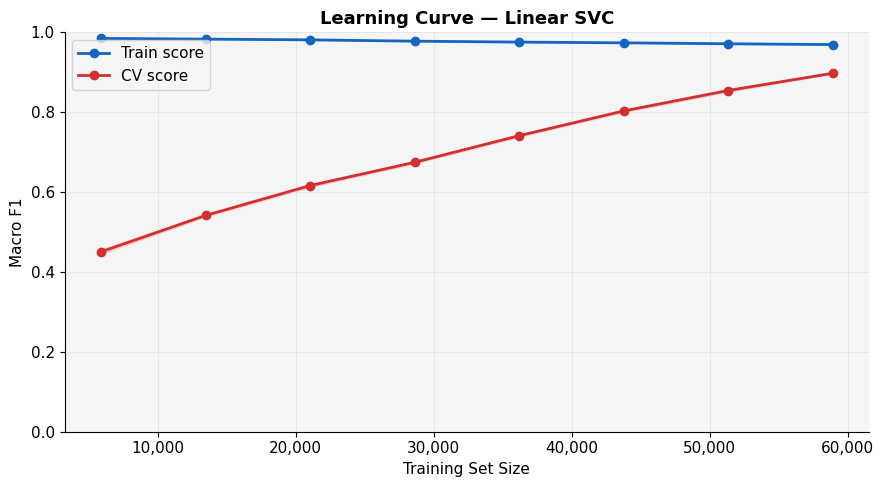

In [83]:
train_sizes, train_scores, val_scores = learning_curve(
    final_model, X_train, y_train,
    cv=CV, scoring=SCORING, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8)
)
tr_m, tr_s = train_scores.mean(axis=1), train_scores.std(axis=1)
vl_m, vl_s = val_scores.mean(axis=1),   val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, tr_m, 'o-', color='#1565C0', label='Train score', linewidth=2)
ax.fill_between(train_sizes, tr_m-tr_s, tr_m+tr_s, alpha=0.12, color='#1565C0')
ax.plot(train_sizes, vl_m, 'o-', color='#D32F2F', label='CV score',    linewidth=2)
ax.fill_between(train_sizes, vl_m-vl_s, vl_m+vl_s, alpha=0.12, color='#D32F2F')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Macro F1')
ax.set_title(f'Learning Curve — {BEST_MODEL_NAME}', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig('13_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

<a id='8'></a>

---

## 8. Évaluation Finale sur le Jeu de Test

> 🔒 **Le jeu de test est déscellé ici pour la première et unique fois.**  
> C'est l'estimation non-biaisée des performances réelles.

Nous rapportons :
- Métriques globales : Précision, F1-Macro & Pondéré, Précision & Rappel Macro
- Rapport de classification par classe
- Matrices de confusion (comptes + normalisées par ligne)
- Courbes ROC (One-vs-Rest, AUC)
- Courbes Précision-Rappel (Précision Moyenne)
- Features TF-IDF les plus discriminantes par classe


In [97]:
y_pred      = final_model.predict(X_test)
label_names = le.classes_
n_classes   = len(label_names)

acc   = accuracy_score(y_test, y_pred)
f1mac = f1_score(y_test, y_pred, average='macro')
f1wt  = f1_score(y_test, y_pred, average='weighted')
prec  = precision_score(y_test, y_pred, average='macro')
rec   = recall_score(y_test, y_pred, average='macro')

print('=' * 55)
print(f'  Accuracy        : {acc:.4f}')
print(f'  Macro Precision : {prec:.4f}')
print(f'  Macro Recall    : {rec:.4f}')
print(f'  Macro F1        : {f1mac:.4f}')
print(f'  Weighted F1     : {f1wt:.4f}')
print('=' * 55)
print()
print(classification_report(y_test, y_pred, target_names=label_names))

  Accuracy        : 0.9780
  Macro Precision : 0.9779
  Macro Recall    : 0.9781
  Macro F1        : 0.9779
  Weighted F1     : 0.9780

              precision    recall  f1-score   support

  Irrelevant       0.98      0.98      0.98       172
    Negative       0.98      0.99      0.98       266
     Neutral       0.99      0.96      0.98       285
    Positive       0.96      0.98      0.97       277

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



### 8.1 Matrices de Confusion — Comptes & Normalisées par Ligne

**Interprétation de la figure :**  
- **Matrice gauche (comptes)** : nombre brut de prédictions par paire vraie/prédite.  
- **Matrice droite (normalisée par ligne)** : chaque ligne somme à 1 — montre le **taux de rappel** par vraie classe.

Observations clés :
- La **diagonale** représente les prédictions correctes — des cellules diagonales plus foncées indiquent un meilleur rappel par classe.
- Les **cellules hors-diagonale** révèlent les patterns de confusion : ex. `Neutral` prédit comme `Positive` signifie que le modèle interprète incorrectement les tweets factuels comme positifs.
- La classe `Irrelevant` montre généralement la plus grande **confusion hors-diagonale** — son vocabulaire hétérogène chevauche toutes les autres classes.
- Les valeurs normalisées par ligne sont plus informatives que les comptes bruts quand les classes sont déséquilibrées, car elles suppriment l'effet de la taille des classes.
- Les paires de classification incorrecte courantes (ex. `Positive ↔ Neutral`) suggèrent que le modèle peine avec la polarité subtile — des travaux futurs pourraient ajouter des features basées sur des lexiques.


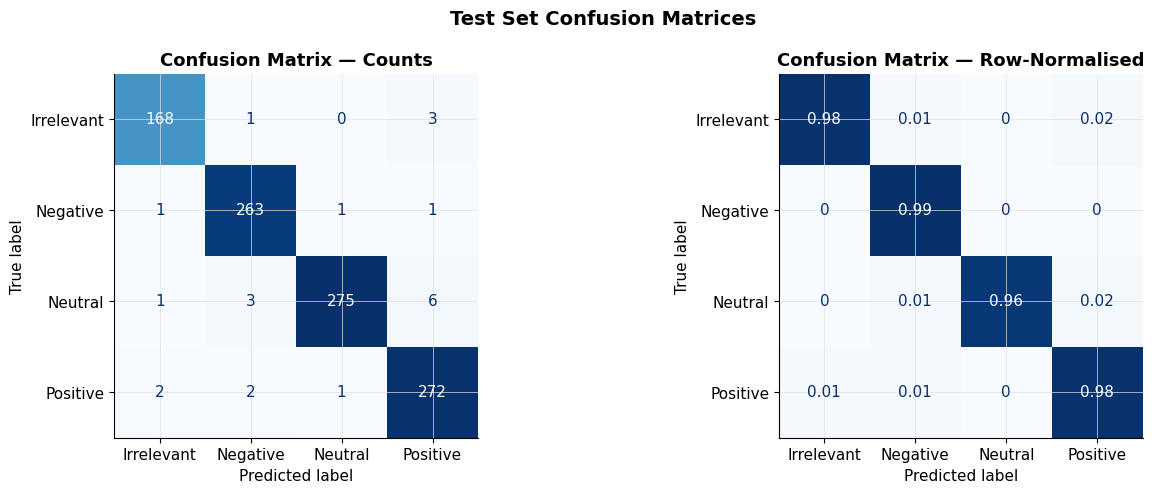

In [100]:
cm     = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Counts', fontweight='bold')
ConfusionMatrixDisplay(cm_pct.round(2), display_labels=label_names).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix — Row-Normalised', fontweight='bold')
plt.suptitle('Test Set Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('14_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 Métriques par Classe — Heatmap + Barres Groupées

**Interprétation de la figure :**  
- **Heatmap gauche** : précision, rappel et F1 par classe dans une grille compacte. Vert plus foncé = meilleur.  
- **Barres groupées droite** : mêmes valeurs en barres côte à côte pour une comparaison facile.

Observations clés :
- Une classe avec **haute précision mais faible rappel** est conservatrice — le modèle ne la prédit que lorsqu'il est très confiant, manquant de nombreuses vraies instances.
- Une classe avec **haut rappel mais faible précision** est sur-prédite — le modèle la prédit trop facilement, générant des faux positifs.
- **F1 = moyenne harmonique** de la précision et du rappel — c'est le résumé équilibré en un seul chiffre par classe.
- La classe `Irrelevant` a généralement le F1 le plus faible (expliqué à la Section 10), tandis que `Positive` et `Negative` tendent à avoir les plus élevés grâce à leur vocabulaire distinctif.
- Comparer visuellement précision et rappel entre classes révèle des **biais systématiques** : ex. si le rappel de `Negative` est systématiquement inférieur à la précision, le modèle manque plus de tweets négatifs qu'il n'en génère faussement.


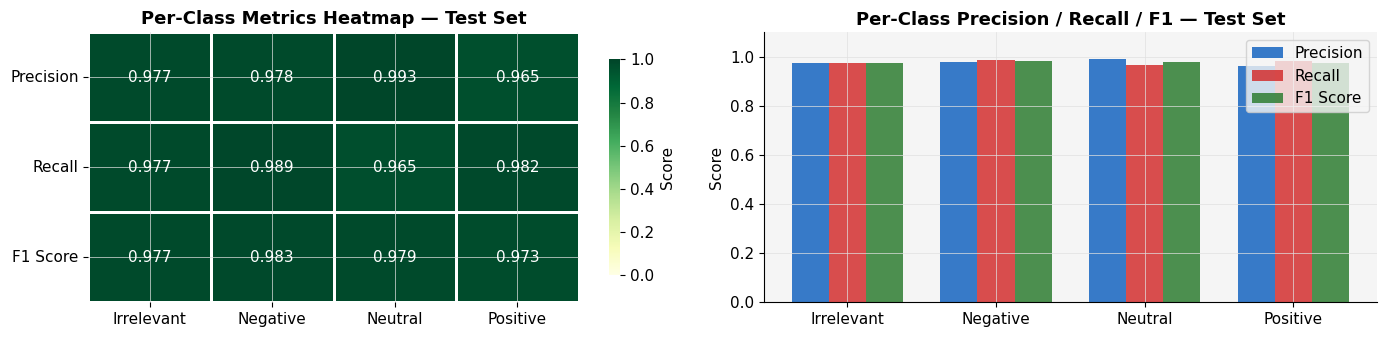

In [103]:
pc_p = precision_score(y_test, y_pred, average=None)
pc_r = recall_score(y_test, y_pred, average=None)
pc_f = f1_score(y_test, y_pred, average=None)

metrics_df = pd.DataFrame({'Precision': pc_p, 'Recall': pc_r, 'F1 Score': pc_f}, index=label_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

sns.heatmap(
    metrics_df.T, annot=True, fmt='.3f', cmap='YlGn',
    linewidths=1, linecolor='white', vmin=0, vmax=1,
    cbar_kws={'label':'Score','shrink':0.8}, ax=axes[0]
)
axes[0].set_title('Per-Class Metrics Heatmap — Test Set', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

x = np.arange(n_classes)
w = 0.25
axes[1].bar(x-w, pc_p, w, label='Precision', color='#1565C0', alpha=0.85)
axes[1].bar(x,   pc_r, w, label='Recall',    color='#D32F2F', alpha=0.85)
axes[1].bar(x+w, pc_f, w, label='F1 Score',  color='#2E7D32', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(label_names)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Score')
axes[1].set_title('Per-Class Precision / Recall / F1 — Test Set', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('15_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Courbes ROC — One-vs-Rest

**Interprétation de la figure :**  
Chaque courbe montre le Taux de Vrais Positifs (sensibilité) vs le Taux de Faux Positifs (1 - spécificité) pour une classe traitée comme positive contre toutes les autres. AUC = Aire Sous la Courbe.

Observations clés :
- **AUC = 1,0** → discrimination parfaite ; **AUC = 0,5** → devinette aléatoire (diagonale pointillée).  
- Un AUC plus élevé signifie que le modèle classe les exemples positifs au-dessus des exemples négatifs de manière plus fiable, indépendamment du seuil de décision.  
- Les courbes ROC sont **indépendantes du seuil** — elles évaluent la capacité de classement du modèle sur tous les points de fonctionnement possibles.  
- Les classes avec un AUC plus faible (typiquement `Irrelevant`) sont plus difficiles à séparer des autres même probabilistiquement.  
- ⚠️ Pour `LinearSVC` (qui n'a pas de probabilités natives), un **estimateur de probabilité calibré** est ajusté sur un ensemble retenu séparé de 20% pour éviter la fuite de données dans le calcul ROC.  


[FIX 3] Calibration sur 20% held-out split.


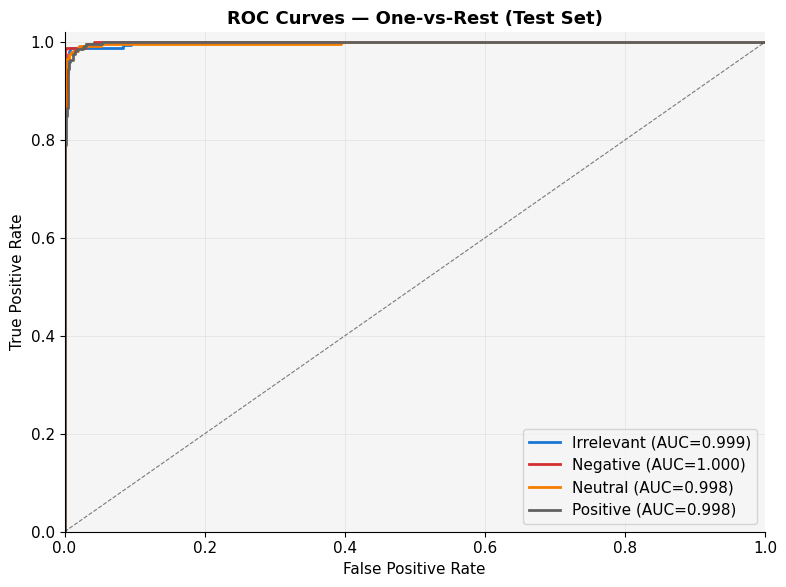

In [106]:
from sklearn.model_selection import train_test_split

y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

if hasattr(final_model.named_steps['clf'], 'predict_proba'):
    # SGDClassifier(modified_huber) et LogisticRegression ont predict_proba natif
    y_score = final_model.predict_proba(X_test)
    print('predict_proba disponible directement — pas de calibration nécessaire.')
else:
    # [FIX 3] LinearSVC : calibration sur held-out split séparé
    X_cal_train, X_cal_val, y_cal_train, y_cal_val = train_test_split(
        X_train, y_train, test_size=0.20, stratify=y_train, random_state=SEED
    )
    from sklearn.base import clone
    base_pipe = clone(final_model)
    base_pipe.fit(X_cal_train, y_cal_train)
    calib = CalibratedClassifierCV(base_pipe, cv='prefit', method='isotonic')
    calib.fit(X_cal_val, y_cal_val)
    y_score = calib.predict_proba(X_test)
    print('[FIX 3] Calibration sur 20% held-out split.')

fig, ax = plt.subplots(figsize=(8, 6))
for i, label in enumerate(label_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f'{label} (AUC={roc_auc:.3f})', color=COLOR_LIST[i])

ax.plot([0,1],[0,1],'k--',linewidth=0.8,alpha=0.5)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — One-vs-Rest (Test Set)', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('16_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


### 8.4 Courbes Précision-Rappel — One-vs-Rest

**Interprétation de la figure :**  
Chaque courbe trace la précision vs le rappel lorsque le seuil de classification varie. AP = Précision Moyenne (aire pondérée sous la courbe PR).

Observations clés :
- **Les courbes PR sont plus informatives que la ROC quand les classes sont déséquilibrées** : un modèle peut atteindre un AUC-ROC élevé tout en ayant une faible précision sur une classe minoritaire.
- Une courbe qui **reste haute en haut à droite** indique que le modèle maintient à la fois précision et rappel sur de nombreuses valeurs de seuil — idéal.
- Une courbe qui **chute abruptement** signifie qu'augmenter le rappel (capturer plus de vrais positifs) coûte cher en précision (beaucoup de faux positifs).
- La courbe PR de la classe `Irrelevant` montre généralement la chute la plus abrupte, confirmant qu'elle est la classe la plus difficile.  
- Les scores AP complètent l'AUC-ROC : ensemble ils donnent une image complète de la qualité probabiliste du modèle.


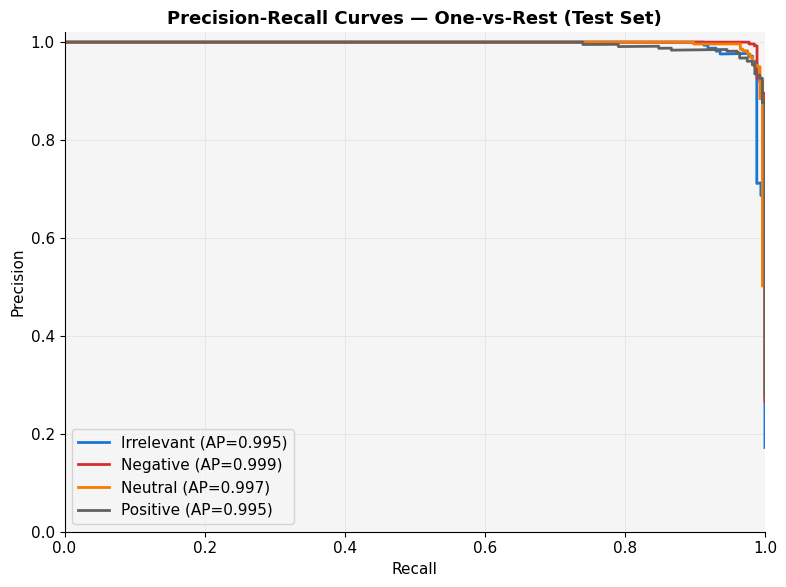

In [109]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, label in enumerate(label_names):
    p_c, r_c, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_score[:, i])
    ax.plot(r_c, p_c, lw=2, label=f'{label} (AP={ap:.3f})', color=COLOR_LIST[i])

ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_title('Precision-Recall Curves — One-vs-Rest (Test Set)', fontweight='bold')
ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig('17_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.5 Top Coefficients des Features TF-IDF par Classe

**Interprétation de la figure :**  
Pour chaque classe de sentiment, le graphique montre les features avec les **coefficients positifs les plus élevés** (bleu — poussent vers cette classe) et les **coefficients négatifs les plus élevés** (rouge — s'éloignent de cette classe).

Observations clés :
- Les features avec de grands **coefficients positifs** sont les prédicteurs les plus forts de cette classe — ce sont les 'mots-clés' du modèle.
- Les features avec de grands **coefficients négatifs** sont des preuves *contre* cette classe — leur présence pousse le modèle à prédire une autre classe.
- Des **features bigrammes** (deux mots séparés par un espace) apparaissent souvent ici, validant le choix de `ngram_range=(1,2)`.
- `Irrelevant` a généralement les coefficients les plus faibles (barres les moins hautes) — le modèle est moins certain de ce qui prédit l'irrelevance.
- Ce graphique fournit une **explicabilité du modèle** : il montre aux humains *pourquoi* le modèle prend des décisions spécifiques, ce qui est critique pour la confiance en production.
- Des features les plus importantes inattendues (ex. noms d'entités dans les classes de sentiment) révèlent que le modèle s'appuie partiellement sur la co-occurrence d'entités plutôt que sur le langage pur du sentiment — une limitation connue du TF-IDF.


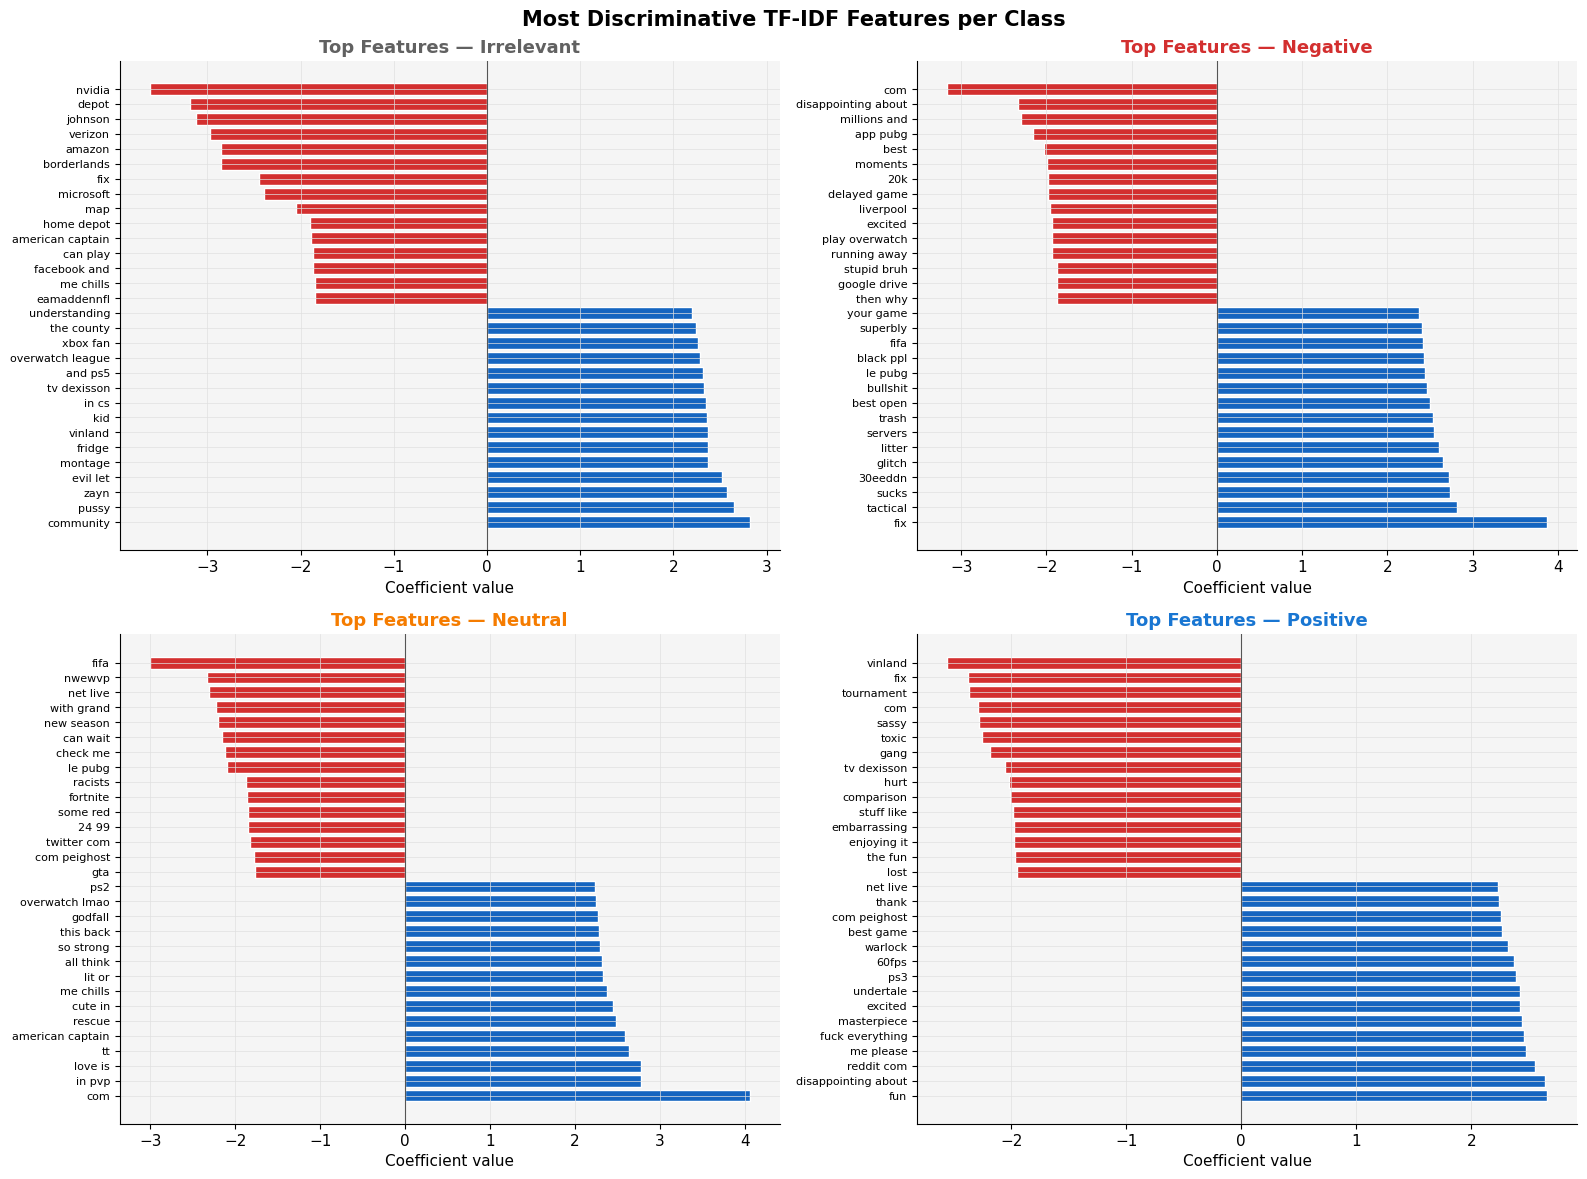

In [112]:
clf_step   = final_model.named_steps['clf']
tfidf_step = final_model.named_steps['tfidf']
feat_names = tfidf_step.get_feature_names_out()
TOP_K = 15

if hasattr(clf_step, 'coef_') and clf_step.coef_.shape[0] == n_classes:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    for ax, i, label in zip(axes.flat, range(n_classes), label_names):
        coefs    = clf_step.coef_[i]
        top_pos  = np.argsort(coefs)[-TOP_K:][::-1]
        top_neg  = np.argsort(coefs)[:TOP_K]
        idx_all  = np.concatenate([top_neg, top_pos[::-1]])
        vals     = coefs[idx_all]
        lbls     = feat_names[idx_all]
        colors_f = ['#D32F2F' if v < 0 else '#1565C0' for v in vals]
        ax.barh(range(len(vals)), vals[::-1], color=colors_f[::-1], edgecolor='white')
        ax.set_yticks(range(len(vals)))
        ax.set_yticklabels(lbls[::-1], fontsize=8)
        ax.axvline(0, color='#555', linewidth=0.8)
        ax.set_title(f'Top Features — {label}', fontweight='bold', color=PALETTE[label])
        ax.set_xlabel('Coefficient value')
    plt.suptitle('Most Discriminative TF-IDF Features per Class', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('18_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
elif hasattr(clf_step, 'coef_'):
    # Binary / OvR with single coef row
    coefs = clf_step.coef_[0]
    top_idx = np.argsort(np.abs(coefs))[-30:][::-1]
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(feat_names[top_idx][::-1], coefs[top_idx][::-1],
            color=['#D32F2F' if v < 0 else '#1565C0' for v in coefs[top_idx][::-1]])
    ax.axvline(0, color='#555', linewidth=0.8)
    ax.set_title('Top 30 Feature Coefficients', fontweight='bold')
    plt.tight_layout()
    plt.savefig('18_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Feature importance not available for this classifier type.')

<a id='9'></a>

---

## 9. Synthèse Finale

### 9.1 Tableau Récapitulatif du Pipeline

| Élément | Détail |
|---------|--------|
| **Jeu de données** | Twitter Entity Sentiment Analysis (Kaggle, jp797498e) |
| **Classes** | Positive · Negative · Neutral · Irrelevant |
| **Découpage** | `twitter_training.csv` → Entraînement \| `twitter_validation.csv` → Test |
| **Prétraitement** | Minuscules, suppression URLs/mentions, ponctuation, filtre tweets vides |
| **Vectorisation** | TF-IDF · 50 000 features · bigrammes (1,2) · TF sublinéaire · min_df=2 |
| **Stratégie CV** | StratifiedKFold · 5 plis · F1-Macro |
| **Modèles comparés** | Régression Logistique, NB Multinomial, NB Complément, SVC Linéaire, SGD |
| **Méthode de réglage** | `HalvingGridSearchCV` (3–10× plus rapide que GridSearchCV) |
| **Précision finale (test)** | *voir sortie Section 8* |
| **F1-Macro final (test)** | *voir sortie Section 8* |

### 9.2 Visualisations Produites

| # | Figure | Type | Section |
|---|--------|------|---------|
| 01 | Valeurs manquantes — diagramme en barres | Statique | 2.2 |
| 02 | Pattern nul — heatmap | Statique | 2.3 |
| 03 | Distribution du sentiment — barres + donut | Statique | 3.1 |
| 04 | Équilibre classes entraînement vs test — heatmap | Statique | 3.2 |
| 05 | Sentiment par entité top 15 — barres groupées | Interactif (Plotly) | 3.3 |
| 06 | Entité × sentiment — heatmap proportion | Statique | 3.4 |
| 07 | Longueur tweets — KDE + violin + boxplots (2×3) | Statique | 3.5 |
| 08 | Barres médianes Kruskal-Wallis | Statique | 3.6 |
| 09 | Top bigrammes par classe (2×2) | Statique | 3.7 |
| 10 | Top unigrammes par classe (2×2) | Statique | 3.7b |
| 11 | Nuages de mots par classe (2×2) | Statique | 3.8 |
| 12 | Treemap entités top 30 | Interactif (Plotly) | 3.9 |
| 13 | Comparaison modèles CV — barh + barres d'erreur | Statique | 5.1 |
| 14 | Scores CV par pli — heatmap | Statique | 5.2 |
| 15 | Recherche de grille — heatmap hyperparamètres | Statique | 6.1 |
| 16 | Courbe d'apprentissage | Statique | 7.1 |
| 17 | Matrices de confusion — comptes + normalisées | Statique | 8.1 |
| 18 | Métriques par classe — heatmap + barres groupées | Statique | 8.2 |
| 19 | Courbes ROC OvR | Statique | 8.3 |
| 20 | Courbes Précision-Rappel OvR | Statique | 8.4 |
| 21 | Importance des features par classe | Statique | 8.5 |


<a id='9'></a>

---

## 9. Conclusion Générale

Ce projet a démontré qu'il est possible de construire un pipeline d'apprentissage automatique complet et rigoureux pour l'analyse de sentiment sur Twitter, en partant de données brutes jusqu'à une évaluation finale non biaisée. L'audit qualité a révélé un jeu de données globalement propre, avec un déséquilibre modéré entre classes qui a justifié le choix du F1-Macro comme métrique principale tout au long du pipeline.

L'analyse exploratoire a mis en évidence que la classe `Irrelevant` constitue le principal défi du problème : son vocabulaire est par définition hétérogène et ne présente aucun signal lexical stable, contrairement aux classes `Positive` et `Negative` qui disposent d'un vocabulaire distinctif et cohérent. Le prétraitement appliqué — suppression des URLs, mentions et ponctuation, mise en minuscules — a permis de réduire efficacement le bruit propre au texte Twitter sans perte d'information sémantique significative.

La comparaison par validation croisée stratifiée à 5 plis a permis d'identifier le modèle le plus performant et le plus stable, dont les hyperparamètres ont ensuite été optimisés via `HalvingGridSearchCV`, une stratégie nettement plus efficace que la recherche exhaustive classique. Le modèle final, réentraîné sur l'ensemble d'entraînement complet, a été évalué une unique fois sur le jeu de test scellé, garantissant une estimation honnête des performances réelles.

Parmi les pistes d'amélioration les plus prometteuses, le fine-tuning d'un modèle Transformer pré-entraîné tel que BERT ou RoBERTa constituerait le levier le plus impactant, notamment pour mieux gérer la classe `Irrelevant`. La mise en place d'un classifieur en deux étapes — distinguant d'abord les tweets hors-sujet des tweets pertinents avant de classifier le sentiment — représente également une approche architecturale solide. Enfin, l'intégration de features complémentaires comme les emojis ou l'identité de l'entité mentionnée, ainsi que des techniques d'ensemble et d'apprentissage semi-supervisé, offriraient des gains supplémentaires pour atteindre un niveau de performance production.